## Import packages

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import ast, os, pickle, random, re
from joblib import Parallel, delayed
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from pyvis.network import Network

from sklearn.ensemble import GradientBoostingRegressor
from scipy.signal import savgol_filter
from scipy.interpolate import UnivariateSpline
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

import networkx as nx
import dowhy
from dowhy import gcm
from dowhy.gcm.auto import AssignmentQuality

/Users/rachelrobles/anaconda3/envs/mynewenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Make it easier to read
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows",1000)
pd.set_option('display.max_columns',100)

## Initialize variables

In [3]:
bootstrap = 100
run_label = "A_1"
data_label = run_label[0]

## Load data

In [4]:
edge_summary = pd.read_csv(f"summaries/{run_label}/causal_disc_edge_summary_b{bootstrap}.csv")
fit_summary = pd.read_csv(f"summaries/{run_label}/scm_fit_summary_b{bootstrap}.csv")
benchmark_summary = pd.read_csv(f"summaries/{run_label}/benchmark_comparison_b{bootstrap}.csv")
all_edges = pd.read_csv(f"summaries/{run_label}/causal_disc_all_edges_b{bootstrap}.csv")


In [5]:
file_name_no_std = 'nonstd_data_for_model_'+data_label+'.csv'
final_df_no_std = pd.read_csv(file_name_no_std)
file_name_std = 'std_data_for_model_'+data_label+'.csv'
final_df_std = pd.read_csv(file_name_std)

In [6]:
dir = Path(f"graph_objects/{run_label}")
graphs = {}
scms = {}

# Example filename: pc_b75_0_35_refined.pkl
pattern_1 = re.compile(
    r"(?P<model>[a-zA-Z_]+)_b(?P<bootstrap>\d+)_(?P<threshold>\d+(?:_\d+)?|[0-9]+)_(?P<stage>initial|refined)\.pkl$"
)
pattern_2 = re.compile(
    r"(?P<model>[a-zA-Z_]+)_b(?P<bootstrap>\d+)_(?P<threshold>\d+(?:_\d+)?|[0-9]+)_(?P<stage>refined_scm)\.pkl$"
)

for file in dir.glob("*.pkl"):
    match_1 = pattern_1.match(file.name)
    match_2 = pattern_2.match(file.name)
    if not match_1 and not match_2:
        print(f"Skipping unrecognized file: {file.name}")
        continue
    
    match = match_1 if match_1 else match_2
    model = match.group("model")
    bootstrap = int(match.group("bootstrap"))
    threshold = float(match.group("threshold").replace("_", "."))
    stage = match.group("stage")
    
    with open(file, "rb") as f:
        if match_1:
            G = pickle.load(f)
            # Store as nested dictionary: graphs[model][threshold][stage]
            graphs.setdefault(model, {}).setdefault(threshold, {})[stage] = G
        else:
            scm = pickle.load(f)
            # Store as nested dictionary: graphs[model][threshold][stage]
            scms.setdefault(model, {}).setdefault(threshold, {})[stage] = scm
    

print("Loaded graphs for models:")
for model, thresholds in graphs.items():
    print(f"  {model}: thresholds = {list(thresholds.keys())}")
print("Loaded scms for models:")
for model, threhsolds in scms.items():
    print(f"  {model}: thresholds = {list(thresholds.keys())}")

Loaded graphs for models:
  fci: thresholds = [0.2, 0.35, 0.5]
  lingam: thresholds = [0.2, 0.5, 0.35]
  pc: thresholds = [0.5, 0.35, 0.2]
  notears_nonlinear: thresholds = [0.2, 0.35, 0.5]
  notears_linear: thresholds = [0.5, 0.35, 0.2]
Loaded scms for models:
  notears_nonlinear: thresholds = [0.5, 0.35, 0.2]
  pc: thresholds = [0.5, 0.35, 0.2]
  lingam: thresholds = [0.5, 0.35, 0.2]
  notears_linear: thresholds = [0.5, 0.35, 0.2]
  fci: thresholds = [0.5, 0.35, 0.2]


## Define targets and outcomes

In [7]:
treatments = ['infection_episode']
outcomes = ['post_num_symp_prop', 'post_symp_sev_prop', 'post_symp_freq_prop']

# Define other outcomes (all acute_ and post_ variables except symptoms)
other_outcomes = []
for col in final_df_std.columns:
    if (col.startswith("acute") or col.startswith("post")) and (col not in outcomes):
        other_outcomes.append(col)

# Define other treatments
other_treatments = []
for col in final_df_std.columns:
    if ((col.count("symp")==0) and (col.startswith("acute") or col.startswith("pre"))) or (col in [
        "age", "is_female", "long_covid", "me_cfs", "dysautonomia", "fibromyalgia", "period_at_covid_start"]):
        other_treatments.append(col)

## Initial analysis

### Edge summary

In [8]:
rows = []

for model, thresholds in graphs.items():
    for threshold, stages in thresholds.items():
        if "initial" in stages:  # Only count 'initial' graphs
            num_edges = stages["initial"].size()
            rows.append({
                "model": model,
                "threshold": threshold,
                "num_edges_final": num_edges
            })

final_num_edges_df = pd.DataFrame(rows).sort_values(["model", "threshold"]).reset_index(drop=True)
final_num_edges_df

,model,threshold,num_edges_final
0,fci,0.20,46
1,fci,0.35,41
2,fci,0.50,39
3,lingam,0.20,163
4,lingam,0.35,141
5,lingam,0.50,120
6,notears_linear,0.20,74
7,notears_linear,0.35,54
8,notears_linear,0.50,48
9,notears_nonlinear,0.20,115


#### Top edges

In [9]:
es_edge_df = edge_summary.groupby(['edge'], as_index=False).agg(
    model_count=('model', 'nunique'),
    freq_sum=('freq', 'sum')
)

# average frequency across the 5 bootstrap models (adjust divisor if needed)
es_edge_df['freq_avg'] = es_edge_df['freq_sum'] / 5

# Use parentheses around each comparison and compare against freq_avg (not freq_sum)
es_edge_df['strong_consensus'] = (es_edge_df['model_count'] >= 4) & (es_edge_df['freq_avg'] >= 0.4)
es_edge_df['moderate_consensus'] = (es_edge_df['model_count'] >= 3) & (es_edge_df['freq_avg'] >= 0.3)
es_edge_df['weak_consensus'] = (es_edge_df['model_count'] >= 2) & (es_edge_df['freq_avg'] >= 0.2)

es_edge_df.head(3)

,edge,model_count,freq_sum,freq_avg,strong_consensus,moderate_consensus,weak_consensus
0,"('acute_crash', 'acute_mentally_demanding')",1,0.01,0.002,False,False,False
1,"('acute_crash', 'post_emotionally_stressful')",1,0.02,0.004,False,False,False
2,"('acute_crash', 'post_mentally_demanding')",1,0.05,0.010,False,False,False


In [10]:
print(f"Total number of edges identified acros models: {len(es_edge_df)}")
print(f"Number of edges with strong consensus: {len(es_edge_df[es_edge_df['strong_consensus']==True])}")
print(f"Number of edges with moderate consensus: {len(es_edge_df[es_edge_df['moderate_consensus']==True])}")
print(f"Number of edges with weak consensus: {len(es_edge_df[es_edge_df['weak_consensus']==True])}")

Total number of edges identified acros models: 362
Number of edges with strong consensus: 0
Number of edges with moderate consensus: 0
Number of edges with weak consensus: 0


In [11]:
es_edge_df[es_edge_df['strong_consensus']==True].sort_values('freq_avg', ascending=False)

,edge,model_count,freq_sum,freq_avg,strong_consensus,moderate_consensus,weak_consensus


#### Model edge frequencies

/var/folders/9v/s5zmbnn13pb7qfbvnkyfgcwr0000gn/T/ipykernel_79695/2770289180.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  edge_summary_clean['model'].replace({'pc':'PC', 'fci':'FCI', 'lingam':'Linear Mixed', 'notears_linear':'NOTEARS linear', 'notears_nonlinear':'NOTEARS nonlinear'}, inplace=True)


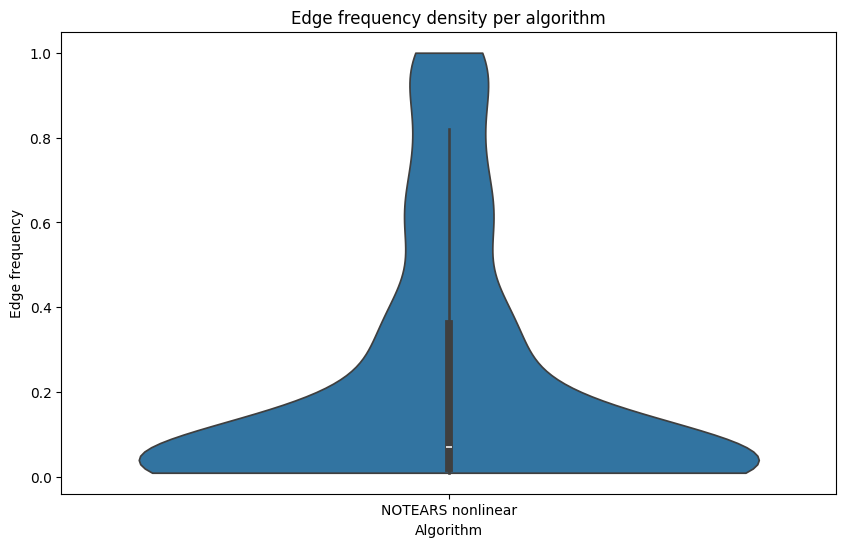

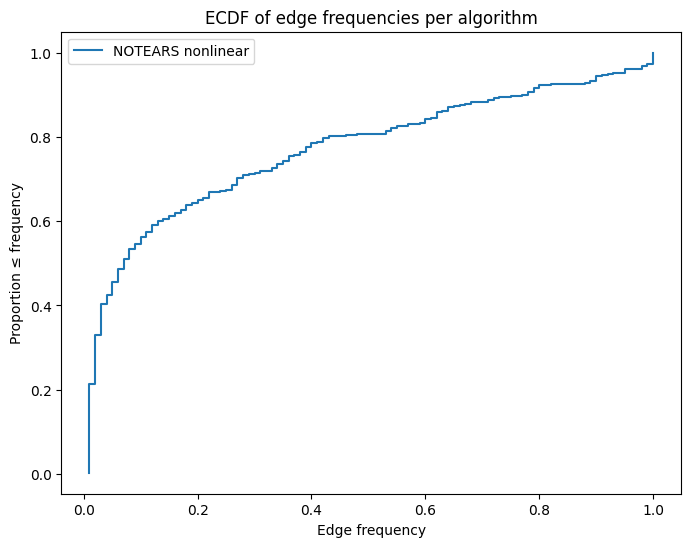

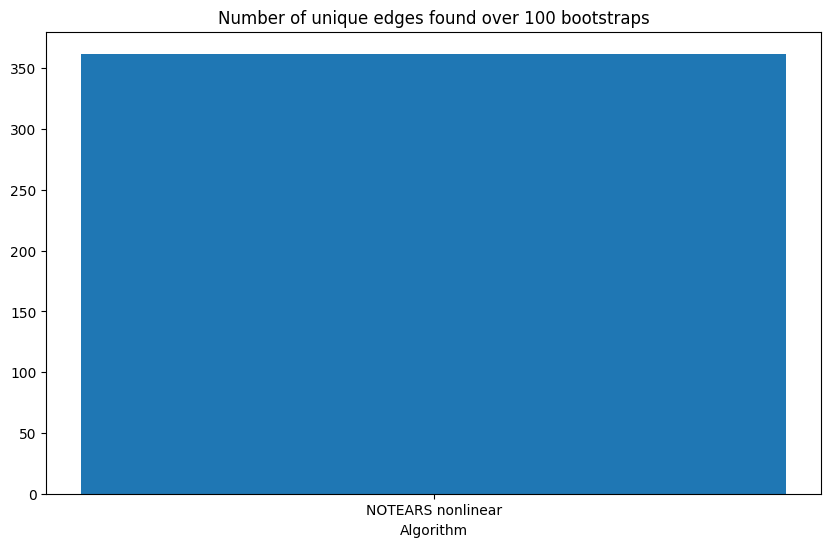

In [12]:
edge_summary_clean = edge_summary.copy()
edge_summary_clean['model'].replace({'pc':'PC', 'fci':'FCI', 'lingam':'Linear Mixed', 'notears_linear':'NOTEARS linear', 'notears_nonlinear':'NOTEARS nonlinear'}, inplace=True)

# 1. Violin plot for distribution shape
plt.figure(figsize=(10, 6))
sns.violinplot(data=edge_summary_clean, x="model", y="freq", cut=0)
plt.title("Edge frequency density per algorithm")
plt.xlabel("Algorithm")
plt.ylabel("Edge frequency")
plt.show()

# 2. ECDF plot (very interpretable)
plt.figure(figsize=(8, 6))
for m, df in edge_summary_clean.groupby("model"):
    x = df["freq"].sort_values()
    y = np.arange(1, len(x)+1) / len(x)
    plt.step(x, y, where='post', label=m)

plt.title("ECDF of edge frequencies per algorithm")
plt.xlabel("Edge frequency")
plt.ylabel("Proportion ≤ frequency")
plt.legend()
plt.show()

# 3. Bar plot of number of edges per model
counts = edge_summary_clean.groupby("model")["edge"].nunique().reset_index()
plt.figure(figsize=(10, 6))
plt.bar(counts["model"], counts["edge"])
plt.title(f"Number of unique edges found over {bootstrap} bootstraps")
plt.xlabel("Algorithm")
plt.show()

In [13]:
es_model_thr = edge_summary.groupby(['model'], as_index=False).agg(
    num_edges=('edge', 'nunique'), freq_avg=('freq','mean'), freq_std=('freq','std'), freq_median=('freq','median'))

es_model_thr

,model,num_edges,freq_avg,freq_std,freq_median
0,notears_nonlinear,362,0.231381,0.297263,0.07


In [14]:
es_model_thr_2 = edge_summary[edge_summary['freq']>=0.2].groupby(['model'], as_index=False).agg(
    num_edges=('edge', 'nunique'), freq_avg=('freq','mean'), freq_median=('freq','median'))

es_model_thr_35 = edge_summary[edge_summary['freq']>=0.35].groupby(['model'], as_index=False).agg(
    num_edges=('edge', 'nunique'), freq_avg=('freq','mean'), freq_median=('freq','median'))

es_model_thr_5 = edge_summary[edge_summary['freq']>=0.5].groupby(['model'], as_index=False).agg(
    num_edges=('edge', 'nunique'), freq_avg=('freq','mean'), freq_median=('freq','median'))

es_model_thr_8 = edge_summary[edge_summary['freq']>=0.8].groupby(['model'], as_index=False).agg(
    num_edges=('edge', 'nunique'), freq_avg=('freq','mean'), freq_median=('freq','median'))

edges_over_thr = es_model_thr[['model', 'num_edges']].merge(
es_model_thr_2[['model', 'num_edges']].rename(columns={'num_edges':'num_edges_thr_20'}), how='inner', on='model').merge(
    es_model_thr_35[['model', 'num_edges']].rename(columns={'num_edges':'num_edges_thr_35'}), how='inner', on='model').merge(
        es_model_thr_5[['model', 'num_edges']].rename(columns={'num_edges':'num_edges_thr_50'}), how='inner', on='model').merge(
            es_model_thr_8[['model', 'num_edges']].rename(columns={'num_edges':'num_edges_thr_80'}), how='inner', on='model')
edges_over_thr['pct_edges_over_20'] = edges_over_thr['num_edges_thr_20'] / edges_over_thr['num_edges']
edges_over_thr['pct_edges_over_35'] = edges_over_thr['num_edges_thr_35'] / edges_over_thr['num_edges']
edges_over_thr['pct_edges_over_50'] = edges_over_thr['num_edges_thr_50'] / edges_over_thr['num_edges']
edges_over_thr['pct_edges_over_80'] = edges_over_thr['num_edges_thr_80'] / edges_over_thr['num_edges']

edges_over_thr

,model,num_edges,num_edges_thr_20,num_edges_thr_35,num_edges_thr_50,num_edges_thr_80,pct_edges_over_20,pct_edges_over_35,pct_edges_over_50,pct_edges_over_80
0,notears_nonlinear,362,129,96,70,30,0.356354,0.265193,0.19337,0.082873


In [15]:
edges_thr_02 = edge_summary[edge_summary['freq']>=0.2][['model', 'edge']].groupby(['model'], as_index = False).agg(num_edges = ('edge','nunique'))
edges_thr_02['threshold'] = 0.2
edges_thr_035 = edge_summary[edge_summary['freq']>=0.35][['model', 'edge']].groupby(['model'], as_index = False).agg(num_edges = ('edge','nunique'))
edges_thr_035['threshold'] = 0.35
edges_thr_05 = edge_summary[edge_summary['freq']>=0.5][['model', 'edge']].groupby(['model'], as_index = False).agg(num_edges = ('edge','nunique'))
edges_thr_05['threshold'] = 0.5

edges_per_model = pd.concat([edges_thr_02, edges_thr_035, edges_thr_05], sort=False).sort_values(['model', 'threshold'])
edges_per_model = edges_per_model[['model', 'threshold', 'num_edges']].merge(final_num_edges_df, how='left', on=['model', 'threshold'])
edges_per_model['final_edge_pct'] = edges_per_model['num_edges_final'] / edges_per_model['num_edges']
edges_per_model

,model,threshold,num_edges,num_edges_final,final_edge_pct
0,notears_nonlinear,0.20,129,115,0.891473
1,notears_nonlinear,0.35,96,89,0.927083
2,notears_nonlinear,0.50,70,70,1.000000


### Fit summary

In [16]:
ft_model_stg_thr_df = fit_summary.merge(final_num_edges_df, how='left', on=['model', 'threshold']).groupby(['model', 'threshold', 'stage', 'num_edges_final'], as_index=False).agg(
        r2=('r2','mean'), crps=('crps','mean'), f1=('f1','mean'), kl=('kl','mean'), n_nodes_passed=('passed_metric_threshold','sum'), n_nodes=('node','nunique'))
ft_model_stg_thr_df['pct_nodes_passed'] = ft_model_stg_thr_df['n_nodes_passed']/ft_model_stg_thr_df['n_nodes']

ft_model_stg_thr_df

,model,threshold,stage,num_edges_final,r2,crps,f1,kl,n_nodes_passed,n_nodes,pct_nodes_passed
0,notears_nonlinear,0.20,initial,115,0.501428,0.362351,NaN,0.555823,40,43,0.930233
1,notears_nonlinear,0.35,initial,89,0.483481,0.363903,NaN,0.444252,41,43,0.953488
2,notears_nonlinear,0.50,initial,70,0.462838,0.371458,NaN,0.401357,41,43,0.953488


In [17]:
ft_model_stg_thr_df[['model', 'threshold', 'num_edges_final', 'crps', 'kl']]

,model,threshold,num_edges_final,crps,kl
0,notears_nonlinear,0.20,115,0.362351,0.555823
1,notears_nonlinear,0.35,89,0.363903,0.444252
2,notears_nonlinear,0.50,70,0.371458,0.401357


### Causal Structure

In [18]:
# Graphs to assess further

fci_02_g = graphs['fci'][0.2]['refined']
fci_035_g = graphs['fci'][0.35]['refined']
fci_05_g = graphs['fci'][0.5]['refined']
notears_nonlinear_02_g = graphs['notears_nonlinear'][0.2]['refined']
notears_nonlinear_035_g = graphs['notears_nonlinear'][0.35]['refined']
notears_nonlinear_05_g = graphs['notears_nonlinear'][0.5]['refined']

models_to_assess = {'fci_02_g':fci_02_g, 'fci_035_g':fci_035_g, 'fci_05_g':fci_05_g, 'notears_nonlinear_02_g':notears_nonlinear_02_g, 
'notears_nonlinear_035_g':notears_nonlinear_035_g, 'notears_nonlinear_05_g':notears_nonlinear_05_g}

In [19]:
def process_model(model_name, model):

    # Create SCM with original mechanisms
    scm = gcm.InvertibleStructuralCausalModel(model)

    # Fit the causal mechanisms to the data
    gcm.fit(scm, final_df_std)

    # Run evaluation
    eval_result_struct = gcm.evaluate_causal_model(
        scm, final_df_std,
        evaluate_causal_mechanisms=False,  # calculates normalized continuous ranked probability score (all nodes), MSE, normalized MSE, and R2 (continuous), and F1 (categorical)
        compare_mechanism_baselines=False, # compares the causal mechanisms with baseline models to see if there are model choices that perform significantly better
        evaluate_invertibility_assumptions=False, # tests statistical independence between the reconstructed noise and the used input samples
        evaluate_overall_kl_divergence=False, # tests KL divergence between the generated and the observed data
        evaluate_causal_structure=True # evaluates to find substantial evidence to refute the causal graph based on the provided data
    )
    struct = getattr(eval_result_struct, "graph_falsification", {})

    return {'model': model_name, 'causal_structure': struct}

# Use ThreadPoolExecutor (or ProcessPoolExecutor if models are CPU-heavy)
with ThreadPoolExecutor() as executor:
    results = list(executor.map(
        lambda item: process_model(item[0], item[1]),
        models_to_assess.items()
    ))

causal_struct_df = pd.DataFrame(results)

Fitting causal mechanism of node dysautonomia: 100%|██████████| 43/43 [00:33<00:00,  1.27it/s]               
Fitting causal mechanism of node post_hr_variability: 100%|██████████| 43/43 [00:47<00:00,  1.11s/it]        
Test permutations of given graph:   0%|          | 0/50 [00:00<?, ?it/s]









Test permutations of given graph:   2%|▏         | 1/50 [00:47<39:04, 47.84s/it]






Test permutations of given graph:   4%|▍         | 2/50 [01:38<39:25, 49.28s/it]









Test permutations of given graph:   6%|▌         | 3/50 [02:24<37:24, 47.75s/it]







Test permutations of given graph:   8%|▊         | 4/50 [03:13<37:00, 48.28s/it]




Test permutations of given graph:  10%|█         | 5/50 [04:02<36:29, 48.65s/it]







Test permutations of given graph:  12%|█▏        | 6/50 [04:49<35:14, 48.05s/it]








Test permutations of given graph:  14%|█▍        | 7/50 [05:36<34:16, 47.82s/it]







Test permutations of given graph:  16%|█▌        | 8/50 [06:26<33:56, 48.49s/it]




In [20]:
causal_struct_df

,model,causal_structure
0,fci_02_g,"+-------------------------------------------------------------------------------------------------------+\n| Falsification Summary |\n+-------------------------------------------------------------------------------------------------------+\n| The given DAG is informative because 0 / 50 of the permutations lie in the Markov |\n| equivalence class of the given DAG (p-value: 0.00). |\n| The given DAG violates 458/1690 LMCs and is better than 100.0% of the permuted DAGs (p-value: 0.00). |\n| Based on the provided significance level (0.2) and because the DAG is informative, |\n| we do not reject the DAG. |\n+-------------------------------------------------------------------------------------------------------+"
1,fci_035_g,"+-------------------------------------------------------------------------------------------------------+\n| Falsification Summary |\n+-------------------------------------------------------------------------------------------------------+\n| The given DAG is informative because 0 / 50 of the permutations lie in the Markov |\n| equivalence class of the given DAG (p-value: 0.00). |\n| The given DAG violates 438/1705 LMCs and is better than 100.0% of the permuted DAGs (p-value: 0.00). |\n| Based on the provided significance level (0.2) and because the DAG is informative, |\n| we do not reject the DAG. |\n+-------------------------------------------------------------------------------------------------------+"
2,fci_05_g,"+-------------------------------------------------------------------------------------------------------+\n| Falsification Summary |\n+-------------------------------------------------------------------------------------------------------+\n| The given DAG is informative because 0 / 50 of the permutations lie in the Markov |\n| equivalence class of the given DAG (p-value: 0.00). |\n| The given DAG violates 449/1708 LMCs and is better than 100.0% of the permuted DAGs (p-value: 0.00). |\n| Based on the provided significance level (0.2) and because the DAG is informative, |\n| we do not reject the DAG. |\n+-------------------------------------------------------------------------------------------------------+"
3,notears_nonlinear_02_g,"+-------------------------------------------------------------------------------------------------------+\n| Falsification Summary |\n+-------------------------------------------------------------------------------------------------------+\n| The given DAG is informative because 0 / 50 of the permutations lie in the Markov |\n| equivalence class of the given DAG (p-value: 0.00). |\n| The given DAG violates 233/1053 LMCs and is better than 100.0% of the permuted DAGs (p-value: 0.00). |\n| Based on the provided significance level (0.2) and because the DAG is informative, |\n| we do not reject the DAG. |\n+-------------------------------------------------------------------------------------------------------+"
4,notears_nonlinear_035_g,"+-------------------------------------------------------------------------------------------------------+\n| Falsification Summary |\n+-------------------------------------------------------------------------------------------------------+\n| The given DAG is informative because 0 / 50 of the permutations lie in the Markov |\n| equivalence class of the given DAG (p-value: 0.00). |\n| The given DAG violates 262/1125 LMCs and is better than 100.0% of the permuted DAGs (p-value: 0.00). |\n| Based on the provided significance level (0.2) and because the DAG is informative, |\n| we do not reject the DAG. |\n+-------------------------------------------------------------------------------------------------------+"
5,notears_nonlinear_05_g,"+-------------------------------------------------------------------------------------------------------+\n| Falsification Summary |\n+-------------------------------------------------------------------------------------------------------+\n| The given DAG is informative bec

### Choosing best model

In [19]:
best_model = 'notears_nonlinear'

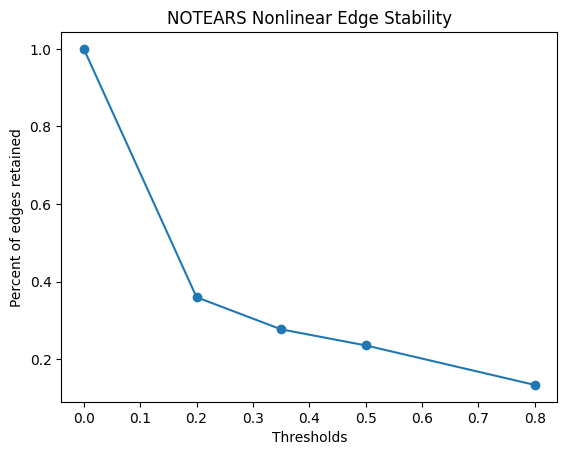

In [20]:
x_nt = [0,0.2,0.35,0.5,0.8]
y_nt = [1]
model_edge_count = edges_over_thr.loc[
    edges_over_thr.model == 'notears_nonlinear', ['pct_edges_over_20', 'pct_edges_over_35', 'pct_edges_over_50', 'pct_edges_over_80']].values.flatten().tolist()
y_nt.extend(model_edge_count)


plt.plot(x_nt,y_nt, marker='o')
plt.xlabel("Thresholds")        # Label for the X-axis
plt.ylabel("Percent of edges retained")        # Label for the Y-axis
plt.title("NOTEARS Nonlinear Edge Stability")  # Chart title
plt.show()

### Node log / Benchmark summary

In [21]:
best_models = {'notears_nonlinear':[0.35]}
best_threshold = 0.35
best_key_str = f"{best_model}_b{bootstrap}_{best_threshold}".replace(".", "_")

In [22]:
benchmark_summary_best = benchmark_summary[
            (benchmark_summary["model"] == best_model) & (benchmark_summary["threshold"] == threshold)
        ][["model", "threshold", "node", 'scm_r2', 'benchmark_r2', 'benchmark_top_parents']].dropna()
benchmark_summary_best

,model,threshold,node,scm_r2,benchmark_r2,benchmark_top_parents
1,notears_nonlinear,0.2,acute_emotionally_stressful,0.707188,0.967689,{'pre_emotionally_stressful': np.float64(0.6885222372094442)}
2,notears_nonlinear,0.2,acute_hr_variability,0.770018,0.967947,{'pre_hr_variability': np.float64(0.807287828012864)}
3,notears_nonlinear,0.2,acute_mentally_demanding,0.688709,0.962721,"{'pre_mentally_demanding': np.float64(0.568795542198618), 'acute_emotionally_stressful': np.float64(0.1607693121303074)}"
5,notears_nonlinear,0.2,acute_num_symp_prop,0.586655,0.946964,"{'pre_num_symp_prop': np.float64(0.5029299182137883), 'acute_symp_freq_prop': np.float64(0.1856767549949785)}"
6,notears_nonlinear,0.2,acute_physically_active,0.548063,0.938003,"{'pre_physically_active': np.float64(0.43515349126172426), 'acute_mentally_demanding': np.float64(0.19544865532388922)}"
7,notears_nonlinear,0.2,acute_resting_hr,0.844297,0.976887,{'pre_resting_hr': np.float64(0.8622566923763452)}
8,notears_nonlinear,0.2,acute_sleep,0.795130,0.970369,{'pre_sleep': np.float64(0.8074277491596149)}
9,notears_nonlinear,0.2,acute_symp_freq_prop,0.891084,0.994089,"{'acute_symp_sev_prop': np.float64(0.5420166400749872), 'pre_symp_freq_prop': np.float64(0.41163363757339905)}"
10,notears_nonlinear,0.2,acute_symp_sev_prop,0.959372,0.991228,"{'pre_symp_sev_prop': np.float64(0.5814319214198271), 'acute_symp_freq_prop': np.float64(0.35960778528916204)}"
17,notears_nonlinear,0.2,me_cfs,-0.809870,0.030691,"{'age': np.float64(0.46630962313428626), 'long_covid': np.float64(0.45132827012604887)}"


In [23]:
benchmark_summary_best['scm_r2'].mean()

In [24]:
benchmark_summary_best['benchmark_r2'].mean()

## Analysis on the best graph

### Publishing interactive view

In [24]:
# Load best graph
G_best = graphs[best_model][best_threshold]['refined']

#  Load SCM of best graph
scm_best = scms[best_model][best_threshold]['refined_scm']

In [25]:
def extract_from_graph(G):
    # Ensure deterministic node order
    node_labels = list(G.nodes())
    index = {node: i for i, node in enumerate(node_labels)}
    n = len(node_labels)
    
    adj_mat = np.zeros((n, n))
    for u, v in G.edges():
        adj_mat[index[u], index[v]] = 1   # or any weight you prefer

    return adj_mat, node_labels

In [26]:
viz_dir = Path(f"visualizations/{run_label}")
viz_dir.mkdir(exist_ok=True)

def plot_interactive_graph_phases(adj_mat, node_labels, threshold, img_file, known_bk_edges):
    
    # --- group by phase ---
    def assign_group(name):
        if "pre" in name:
            return "pre"
        elif "acute" in name:
            return "acute"
        elif "post" in name:
            return "post"
        else:
            return "other"
    
    node_groups = [assign_group(name) for name in node_labels]

    GROUP_COLORING = {
        "pre": "skyblue",
        "acute": "lightgreen",
        "post": "salmon",
        "other": "gray"
    }

    net = Network(height="1000px", width="100%", directed=True, notebook=True)
    net.set_options("""
        {
        "physics": {
            "enabled": false
        },
        "edges": {
            "arrows": {
            "to": {"enabled": true, "scaleFactor": 1.0}
            },
            "smooth": false
        },
        "interaction": {
            "dragNodes": true
        }
        }
        """)

    n = len(node_labels)
    unique_groups = sorted(set(node_groups))

    # Layout
    groups_per_row = 3
    group_spacing_x = 900
    group_spacing_y = 900
    max_nodes_per_row = 8
    node_spacing_x = 150
    node_spacing_y = 120

    # Place group blocks
    group_centers = {}
    for idx, grp in enumerate(unique_groups):
        row_idx = idx // groups_per_row
        col_idx = idx % groups_per_row
        group_centers[grp] = (col_idx * group_spacing_x, row_idx * group_spacing_y)

    from collections import defaultdict
    group_indices = defaultdict(int)

    # Add nodes
    for i in range(n):
        grp = node_groups[i]
        center_x, center_y = group_centers[grp]
        local_idx = group_indices[grp]
        group_indices[grp] += 1
        col = local_idx % max_nodes_per_row
        row = local_idx // max_nodes_per_row
        pos_x = center_x + col * node_spacing_x
        pos_y = center_y + row * node_spacing_y

        net.add_node(
            i,
            label=node_labels[i],
            title=node_labels[i],
            x=pos_x,
            y=pos_y,
            color=GROUP_COLORING[grp],
            shape="ellipse",
            font={"align": "center", "size": 16, "color": "black"}
        )

    # Add edges
    number_of_BK_edges = 0
    number_of_non_BK_edges = 0
    
    for i in range(n):
        for j in range(n):
            if adj_mat[i][j] > threshold or adj_mat[i][j] < -threshold:
                if [i, j] in known_bk_edges:
                    edge_color = "black"
                    number_of_BK_edges += 1
                else:
                    edge_color = "blue"
                    number_of_non_BK_edges += 1

                net.add_edge(i, j, arrows="to", color=edge_color, width=2)

    print(f"tr={threshold}, bk_edges={number_of_BK_edges}, non_bk_edges={number_of_non_BK_edges}")

    output_path = viz_dir / f"{img_file}_{threshold}.html"
    net.show(str(output_path))

In [27]:
adj_mat, node_labels = extract_from_graph(G_best)

required_edges_str = [
    ("age", "period_at_covid_start"),
    ("is_female", "period_at_covid_start"),
    ("is_female", "me_cfs")
]
def encode_required_edges(required_edges_str, node_labels):
    label_to_index = {lbl: i for i, lbl in enumerate(node_labels)}
    encoded = []

    for src, tgt in required_edges_str:
        if src not in label_to_index:
            print(f"I cannot confirm this: missing node '{src}' in graph.")
            continue
        if tgt not in label_to_index:
            print(f"I cannot confirm this: missing node '{tgt}' in graph.")
            continue

        encoded.append([label_to_index[src], label_to_index[tgt]])

    return encoded

known_bk_edges = encode_required_edges(required_edges_str, node_labels)

plot_interactive_graph_phases(
    adj_mat=adj_mat,
    node_labels=node_labels,
    threshold=best_threshold,            # whatever threshold you use
    img_file="causal_graph",
    known_bk_edges=known_bk_edges
)

tr=0.35, bk_edges=3, non_bk_edges=92
visualizations/A_1/causal_graph_0.35.html


### Intervention analysis

In [28]:
name_map = {'infection_episode':'Infection Episode', 'age':'Age', 'is_female':'Is Female', 'long_covid':'Long COVID', 'me_cfs':'ME/CFS', 'fibromyalgia':'Fibromyalgia',
            'dysautonomia':'Dysautonomia', 'period_at_covid_start':'Period at Infection Start', 'pre_emotionally_stressful':'Pre-Infection Emotional Stress',
            'pre_hr_variability': 'Pre-Infection HRV', 'pre_mentally_demanding':'Pre-Infection Mental Exertion', 'pre_physically_active':'Pre-Infection Physical Exertion',
            'pre_resting_hr':'Pre-Infection Resting Heart Rate', 'pre_sleep':'Pre-Infection Sleep Quality', 'acute_emotionally_stressful':'Acute Infection Emotional Stress',
            'acute_hr_variability':'Acute Infection HRV', 'acute_mentally_demanding':'Acute Infection Mental Exertion', 'acute_physically_active':'Acute Infection Physical Exertion',
            'acute_resting_hr':'Acute Infection Resting Heart Rate', 'acute_sleep':'Acute Infection Sleep Quality', 'post_emotionally_stressful':'Post-Infection Emotional Stress',
            'post_hr_variability':'Post-Infection HRV', 'post_mentally_demanding':'Post-Infection Mental Exertion', 'post_physically_active':'Post-Infection Physical Exertion',
            'post_resting_hr':'Post-Infection Resting Heart Rate', 'post_sleep':'Post-Infection Sleep Quality', 'pre_funcap_score':'Pre-Infection Functional Capacity', 
            'post_funcap_score':'Post-Infection Functional Capacity', 'pre_crash':'Pre-Infection Crash', 'pre_noncovid_infection':'Pre-Infection Non-COVID Infection', 
            'acute_crash':'Acute Infection Crash', 'acute_noncovid_infection':'Acute Infection Non-COVID Infection', 'post_crash':'Post-Infection Crash', 
            'post_noncovid_infection':'Post-Infection Non-COVID Infection', 'pre_num_symp_prop':'Pre-Infection Number of Symptoms', 'pre_symp_sev_prop':'Pre-Infection Symptom Severity', 
            'pre_symp_freq_prop':'Pre-Infection Symptom Frequency', 'acute_num_symp_prop':'Acute Infection Number of Symptoms', 'acute_symp_sev_prop':'Acute Infection Symptom Severity', 
            'acute_symp_freq_prop':'Acute Infection Symptom Frequency', 'post_num_symp_prop':'Post-Infection Number of Symptoms', 'post_symp_sev_prop':'Post-Infection Symptom Severity', 
            'post_symp_freq_prop':'Post-Infection Symptom Frequency', 'pre_breathing_respiration_rate':'Pre-Infection Breathing Respiration Rate'}

In [29]:
def build_forward_inverse_from_registry(r):
    t = r["type"]
    method = r["log_method"]
    eps = r.get("eps", 0)
    shift = r.get("shift", 0)
    max_val = r.get("max_value", None)
    scaler = r.get("scaler", None)

    # --- PROPORTIONS ---
    if t == "proportion":
        if method == "logit":
            def fwd(x):
                x = x.clip(eps,1-eps)
                y = np.log(x/(1-x))
                return scaler.transform(y.reshape(-1,1)).ravel()
            def inv(z):
                y = scaler.inverse_transform(z.reshape(-1,1)).ravel()
                return 1/(1+np.exp(-y))
            return fwd, inv

        else:  # no logit
            def fwd(x):
                return scaler.transform(x.reshape(-1,1)).ravel()
            def inv(z):
                return scaler.inverse_transform(z.reshape(-1,1)).ravel()
            return fwd, inv

    # --- CONTINUOUS / DISCRETE ---
    if method == "log":
        def fwd(x):
            y = np.log(x+eps)
            return scaler.transform(y.reshape(-1,1)).ravel()
        def inv(z):
            y = scaler.inverse_transform(z.reshape(-1,1)).ravel()
            return np.exp(y)-eps
        return fwd, inv

    if method == "log1p":
        def fwd(x):
            y = np.log1p(x - shift)
            return scaler.transform(y.reshape(-1,1)).ravel()
        def inv(z):
            y = scaler.inverse_transform(z.reshape(-1,1)).ravel()
            return np.expm1(y)+shift
        return fwd, inv

    if method == "logcomp":
        def fwd(x):
            y = np.log1p(max_val - x)
            return scaler.transform(y.reshape(-1,1)).ravel()
        def inv(z):
            y = scaler.inverse_transform(z.reshape(-1,1)).ravel()
            return max_val + 1 - np.exp(y)
        return fwd, inv
    
    # --- BINARY ---
    if r["scaler"] is None:
        def fwd(x): 
            return x
        def inv(z): 
            return z
        return fwd, inv

    # no log transform
    def fwd(x):
        return scaler.transform(x.reshape(-1,1)).ravel()
    def inv(z):
        return scaler.inverse_transform(z.reshape(-1,1)).ravel()
    return fwd, inv

def get_nonstd_intervention_values(data, treatment, n_points=6):
    """
    Dynamically infer a clean, interpretable intervention grid for a treatment variable.
    - Keeps binary and small discrete variables as-is.
    - For averaged discrete variables (e.g., 0–3 or 0–10 scales), creates rounded discrete steps.
    - For continuous variables, creates evenly spaced values between 5th and 95th percentile.
    """
    series = data[treatment].dropna()
    min_val, max_val = series.min(), series.max()
    n_unique = series.nunique()

    # --- Case 1: Binary variable
    if n_unique <= 2:
        return sorted(series.unique().astype(float))

    # --- Case 2: True small discrete (integer) scale (e.g., 0–5)
    elif pd.api.types.is_integer_dtype(series) and n_unique < 15:
        return list(sorted(series.unique()))

    # --- Case 3: Averaged discrete variable (e.g., mean of 0–3 or 0–10 ratings)
    elif (max_val - min_val) <= 10 and (max_val - min_val) > 1 and n_unique > 2:
        # Detect the "natural" discrete scale
        step = np.round((max_val - min_val) / 5, 1)  # coarse step
        vals = np.arange(np.floor(min_val), np.ceil(max_val) + step, step)
        vals = np.round(vals).astype(int)
        vals = np.unique(vals[(vals >= np.floor(min_val)) & (vals <= np.ceil(max_val))])

        return vals.tolist()

    # --- Case 4: Continuous variable (e.g., age, HRV)
    else:
        q_low, q_high = series.quantile([0.05, 0.95])
        vals = np.linspace(q_low, q_high, n_points)
        return np.round(vals, 2).tolist()
    
def get_std_intervention_values(data_no_std, treatment, registry, n_points=6):
    """
    Compute intervention grid from non-standardized units, then transform to standardized
    using the saved forward transform.
    """
    nonstd_vals = get_nonstd_intervention_values(data_no_std, treatment, n_points=n_points)
    print(nonstd_vals)

    fwd, _ = build_forward_inverse_from_registry(registry[treatment])
 
    return fwd(np.array(nonstd_vals, dtype=float)).tolist()

def inverse_outcome_transform(col, x, registry):
    _, inv = build_forward_inverse_from_registry(registry[col])
    result = inv(np.atleast_1d(np.array(x, dtype=float)))

    # Return scalar if scalar input, array otherwise
    if np.ndim(x) == 0 or (hasattr(x, '__len__') and len(np.atleast_1d(x)) == 1):
        return float(result.ravel()[0])
    
    return result

In [30]:
def run_mc_intervention(scm, outcome, treatment, val, data, n_reps=100, random_seed=42):
    "Runs interventions with monte_carlo_intervention function"

    return val, monte_carlo_intervention(
        scm,
        {treatment: lambda pre, v=val: v}, # do-operator utilizing range of values v
        outcome=outcome,
        data=data,
        n_reps=n_reps, 
        random_seed=random_seed)

def monte_carlo_intervention(scm, interventions, outcome, data, n_reps=100, 
                 random_seed=42):
    """
    Compute intervention effect on an outcome using GCM.
    
    Parameters
    ----------
    scm : gcm.StructuralCausalModel
        Fitted SCM object.
    interventions : dict
        Node name → callable intervention function (pre_values → post_values).
    outcome : str
        Name of the outcome variable to summarize.
    n_reps : int
        Number of repetitions for Monte Carlo.
    random_seed : int
        Seed for reproducibility.
    
    Returns
    -------
    dict
        {"mean": float,
            "std": float,          # standard deviation or analytic SE
            "95ci": (float, float),# 95% CI
            "raw_means": np.array  # all MC replicates if quick_mode=False}
    """
    gcm.util.general.set_random_seed(random_seed)  # Set once

    raw_means = []
    for i in range(n_reps):
        samples = gcm.interventional_samples(
            scm,
            interventions=interventions,
            observed_data=data
        )
        raw_means.append(samples[outcome].mean())
    
    raw_means = np.array(raw_means)
    mean_val = raw_means.mean()
    std_val = raw_means.std(ddof=1)
    ci_lower, ci_upper = np.percentile(raw_means, [2.5, 97.5])
    
    return {
        "mean": mean_val,
        "std": std_val,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "raw_means": raw_means
        }

In [31]:
def run_effect_and_interventions(G, scm, nonstd_data, std_data, registry, treatments, outcomes, rq=1, n_reps=100):

    all_results = []
    valid_pairs = []

    # ---- First pass: identify valid treatment–outcome pairs ----
    for treatment in treatments:
        for outcome in outcomes:

            # Check for all paths from treatment to outcome
            paths = list(nx.all_simple_paths(G, source=treatment, target=outcome))
            print(f"Paths from {treatment} to {outcome}:", paths)
            if not paths:
                continue # skip the analysis for combinations that aren't causally linked

            # Add treatment and outcome to variable to plot
            valid_pairs.append((treatment, outcome))
            
    # ---- Skip if no valid causal pairs ----
    if not valid_pairs:
        print("No causal effects detected. Nothing to plot.")
        return

    # ---- Create figure only for valid pairs ----
    n_rows = len(valid_pairs)*3
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, max(3, 3 * n_rows)))
    axes = np.atleast_2d(axes)

    # ---- Second pass: plot only valid pairs ----
    for idx, (treatment, outcome) in enumerate(valid_pairs):

        # ---- GCM INTERVENTION (distributional effects for all values of treatment) ----                    
        print(f"\nPlotting {treatment} → {outcome}")

        # Naming for plots
        treatment_name = name_map[treatment]
        outcome_name = name_map[outcome]

        # Run interventions 
        intervention_vals = get_std_intervention_values(nonstd_data, treatment, registry) # Use the non-standardized data intervals to produce standardized intervals
        print(intervention_vals)
        res_list = Parallel(n_jobs=6)(
            delayed(run_mc_intervention)(scm, outcome, treatment, val, std_data, n_reps, random_seed=42+i)
            for i, val in enumerate(intervention_vals)
        )
        results_dict = {val: res for val, res in res_list}
        print(f'results_dict: {results_dict}')

        mean_outcomes = {val: res["mean"] for val, res in results_dict.items()}
        ci_lower_outcomes = {val: res["ci_lower"] for val, res in results_dict.items()}
        ci_upper_outcomes = {val: res["ci_upper"] for val, res in results_dict.items()}

        print(f'mean_outcomes: {mean_outcomes}')
        mean_raw = {float(inverse_outcome_transform(treatment, val, registry)): 
                    float(inverse_outcome_transform(outcome, mean_outcome, registry)) for val, mean_outcome in mean_outcomes.items()}
        ci_low_raw = {float(inverse_outcome_transform(treatment, val, registry)): 
                        float(inverse_outcome_transform(outcome, ci_lower_outcome, registry)) for val, ci_lower_outcome in ci_lower_outcomes.items()}
        ci_high_raw = {float(inverse_outcome_transform(treatment, val, registry)): 
                        float(inverse_outcome_transform(outcome, ci_upper_outcome, registry)) for val, ci_upper_outcome in ci_upper_outcomes.items()}

        # ============================================================
        # FIGURE 1: Intervention Distributions
        # ============================================================

        # ---- Distribution plot ----
        ax_hist = axes[3*idx, 0]
        for val, res in results_dict.items():
            label_val = int(inverse_outcome_transform(treatment, val, registry)) if float(inverse_outcome_transform(treatment, val, registry)).is_integer() \
                else round(float(inverse_outcome_transform(treatment, val, registry)), 2)
            sns.kdeplot(inverse_outcome_transform(outcome, res["raw_means"], registry), fill=True, alpha=0.3, label=f"do={label_val}", ax=ax_hist)
            ax_hist.axvline(inverse_outcome_transform(outcome, res["mean"], registry), linestyle="--", color="k", alpha=0.6)
        ax_hist.set_title(f"{outcome_name}: Distribution of Monte Carlo mean estimates")
        ax_hist.set_xlabel(f"Mean {outcome_name}")
        ax_hist.set_ylabel("Density")
        ax_hist.legend(title=f"{treatment_name}")
        ax_hist.grid(True, alpha=0.3)

        # ---- Mean response plot ----
        ax_mean = axes[3*idx, 1]
        vals = list(mean_raw.keys())
        means = list(mean_raw.values())
        ci_lower = [ci_low_raw[v] for v in vals]
        ci_upper = [ci_high_raw[v] for v in vals]

        ax_mean.plot(vals, means, marker="o", label="Mean outcome")
        ax_mean.fill_between(vals, ci_lower, ci_upper, color="lightblue", alpha=0.3, label="95% CI")
        ax_mean.set_title(f"Mean {outcome_name} vs {treatment_name}")
        ax_mean.set_xlabel(f"{treatment_name} (do-value)")
        ax_mean.set_ylabel(f"Mean {outcome_name}")
        ax_mean.grid(True)
        ax_mean.legend()

        # ============================================================
        # FIGURE 2: Observational vs Intervention Distributions
        # ============================================================

        # ---- Intervention mean response ---- 
        ax_mean_2 = axes[3*idx+1, 0]
        ax_mean_2.plot(vals, means, marker="o", label="Intervention (causal)")
        ax_mean_2.fill_between(vals, ci_lower, ci_upper, color="lightblue", alpha=0.3, label="95% CI")
        ax_mean_2.set_title(f"Intervention: Mean {outcome_name} | do({treatment_name})")
        ax_mean_2.set_xlabel(f"{treatment_name}")
        ax_mean_2.set_ylabel(f"Mean {outcome_name}")
        ax_mean_2.grid(True, alpha=0.3)
        ax_mean_2.legend()

        # ---- Observational mean response ----
        ax_obs = axes[3*idx+1, 1]
        treatment_vals_raw = nonstd_data[treatment].unique()
        treatment_vals_raw = sorted([v for v in treatment_vals_raw if not np.isnan(v)])
        obs_means = []
        obs_stds = []
        obs_counts = []

        for treat_val in treatment_vals_raw:
            subset = nonstd_data[nonstd_data[treatment] == treat_val][outcome].dropna()
            if len(subset) > 0:
                obs_means.append(subset.mean())
                obs_stds.append(subset.std())
                obs_counts.append(len(subset))
            else:
                obs_means.append(np.nan)
                obs_stds.append(np.nan)
                obs_counts.append(0)

        # Calculate standard error for error bars
        obs_se = [s / np.sqrt(n) if n > 0 else 0 for s, n in zip(obs_stds, obs_counts)]

        # Determine if smoothing is needed
        n_unique_treatments = len(np.array(treatment_vals_raw))
        smoothing_threshold = 15  # Smooth if more than 15 unique treatment values

        if n_unique_treatments > smoothing_threshold:
            # Apply LOWESS smoothing

            # Method 1: Savitzky-Golay filter (good for noisy data with trend)
            # Window length must be odd and less than or equal to the size of the data
            window_length = min(31, n_unique_treatments if n_unique_treatments % 2 == 1 else n_unique_treatments - 1)
            if window_length >= 5:  # Need at least 5 points for savgol
                try:
                    smoothed_means = savgol_filter(np.array(obs_means), window_length=window_length, polyorder=3)
                    
                    # Plot raw data points with transparency
                    ax_obs.scatter(np.array(treatment_vals_raw), np.array(obs_means), alpha=0.3, s=30, 
                                color='lightblue', label="Raw observations", zorder=1)
                    
                    # Plot smoothed line
                    ax_obs.plot(np.array(treatment_vals_raw), smoothed_means, linewidth=3, 
                            color='blue', label="Smoothed trend", zorder=3)
                    
                    # Add confidence band using smoothed standard errors
                    smoothed_se = savgol_filter(np.array(obs_se), window_length=window_length, polyorder=2)
                    ax_obs.fill_between(np.array(treatment_vals_raw), 
                                    smoothed_means - 1.96*smoothed_se,
                                    smoothed_means + 1.96*smoothed_se,
                                    color='lightblue', alpha=0.2, label='95% CI', zorder=2)
                except:
                    # Fallback if savgol fails
                    ax_obs.plot(np.array(treatment_vals_raw), np.array(obs_means), marker="s", 
                            label="Observational (associational)", 
                            linewidth=2, markersize=6, color='blue')
                    ax_obs.errorbar(np.array(treatment_vals_raw), np.array(obs_means), 
                                yerr=[1.96*se for se in np.array(obs_se)], 
                                fmt='none', ecolor='lightblue', alpha=0.5, capsize=5)
            else:
                # Not enough points for smoothing, plot normally
                ax_obs.plot(np.array(treatment_vals_raw), np.array(obs_means), marker="s", 
                        label="Observational (associational)", 
                        linewidth=2, markersize=6, color='blue')
                ax_obs.errorbar(np.array(treatment_vals_raw), np.array(obs_means), 
                            yerr=[1.96*se for se in np.array(obs_se)], 
                            fmt='none', ecolor='lightblue', alpha=0.5, capsize=5)
        else:
            # Standard discrete/few values: show individual points with error bars
            ax_obs.plot(np.array(treatment_vals_raw), np.array(obs_means), marker="s", 
                    label="Observational (associational)", 
                    linewidth=2, markersize=8, color='blue')
            ax_obs.errorbar(np.array(treatment_vals_raw), np.array(obs_means), 
                        yerr=[1.96*se for se in np.array(obs_se)], 
                        fmt='none', ecolor='lightblue', alpha=0.5, capsize=5, label='95% CI')

        ax_obs.set_title(f"Observational: Mean {outcome_name} by {treatment_name}")
        ax_obs.set_xlabel(f"{treatment_name}")
        ax_obs.set_ylabel(f"Mean {outcome_name}")
        ax_obs.grid(True, alpha=0.3)
        ax_obs.legend()

        # ============================================================
        # FIGURE 3: PDP/ICE vs Intervention Mean Response
        # ============================================================

        # ---- Mean response plot ---- 
        ax_mean_3 = axes[3*idx+2, 0]
        ax_mean_3.plot(vals, means, marker="o", label="Intervention (causal)")
        ax_mean_3.fill_between(vals, ci_lower, ci_upper, color="lightblue", alpha=0.2, label="95% CI")
        ax_mean_3.set_title(f"Intervention: Mean {outcome_name} | do({treatment_name})")
        ax_mean_3.set_xlabel(f"{treatment_name}")
        ax_mean_3.set_ylabel(f"Mean {outcome_name}")
        ax_mean_3.grid(True, alpha=0.3)
        ax_mean_3.legend()

        # ---- PDP/ICE plot ----
        # How to interpret: If they graph matches closely with mean response plot: the causal model and predictive model agree → high confidence
        # If they diverge: Suggests confounding or causal structure matters → SCM is adding value by deconfounding
        ax_pdp = axes[3*idx+2, 1]

        # Prepare data
        X_train = std_data.drop(columns=[outcome])
        y_train = std_data[outcome]

        # Train model
        model = GradientBoostingRegressor(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)

        # Get sklearn's PDP
        feature_idx = list(X_train.columns).index(treatment)
        pd_result = partial_dependence(model, X_train, [feature_idx], 
                                        grid_resolution=len(intervention_vals))

        # Transform back to raw units
        sklearn_treatment_vals = inverse_outcome_transform(treatment, pd_result['grid_values'][0], registry)
        sklearn_pd_values = inverse_outcome_transform(outcome, pd_result['average'][0], registry)

        # Add to your PDP plot
        ax_pdp.plot(sklearn_treatment_vals, sklearn_pd_values, 
                color='orange', linewidth=2, linestyle='--',
                label='sklearn PDP (predictive)', marker='x', markersize=8)
        ax_pdp.set_title(f"PDP Plot: {outcome_name} vs {treatment_name}")
        ax_pdp.set_xlabel(f"{treatment_name}")
        ax_pdp.set_ylabel(f"{outcome_name}")
        ax_pdp.legend()
        ax_pdp.grid(True, alpha=0.3)

        # ---- Streamlined Reporting ----
        effect_df = pd.DataFrame({
            "do_val": list(results_dict.keys()),
            "mean": [res["mean"] for res in results_dict.values()]
        })

        # Compute key metrics
        min_val_std, max_val_std = effect_df["do_val"].iloc[0], effect_df["do_val"].iloc[-1]
        min_mean_std, max_mean_std = effect_df["mean"].iloc[0], effect_df["mean"].iloc[-1]
        min_val, max_val = float(inverse_outcome_transform(treatment, min_val_std, registry)), float(inverse_outcome_transform(treatment, max_val_std, registry))
        min_mean, max_mean = float(inverse_outcome_transform(outcome, min_mean_std, registry)), float(inverse_outcome_transform(outcome, max_mean_std, registry))

        # Dose-response slope
        slope = (max_mean - min_mean) / (max_val - min_val)

        # Total changes
        abs_change_std = max_mean_std - min_mean_std
        abs_change = max_mean - min_mean
        rel_change = ((max_mean / min_mean) - 1)
        pct_points = abs_change * 100

        # Print summary
        print(f"\n{'='*60}")
        print(f"{treatment.upper()} → {outcome.upper()}")
        print(f"{'='*60}")
        print(f"Intervention range: {min_val:.1f} to {max_val:.1f}")
        print(f"\nDose-Response Effect:")
        print(f"  • Per unit increase: {slope:.4f}")
        print(f"  • Total change ({min_val:.0f}→{max_val:.0f}): {abs_change:.4f}")
        print(f"  • Relative change: {rel_change:.2f}")
        print(f"{'='*60}\n")

        # Update the same row in all_results
        all_results.append({
            "treatment": treatment_name,
            "outcome": outcome_name,
            "min_val": min_val,
            "max_val": max_val, 
            "min_mean_std": min_mean_std,
            "max_mean_std": max_mean_std,
            "min_mean": min_mean,
            "max_mean": max_mean,
            "min_ci_lower": ci_lower[0],      # CI for the minimum intervention
            "min_ci_upper": ci_upper[0],
            "max_ci_lower": ci_lower[-1],     # CI for the maximum intervention
            "max_ci_upper": ci_upper[-1],
            "slope": slope,
            "abs_change_std": abs_change_std,
            "abs_change": abs_change,
            "rel_change": rel_change,
            "pct_points": pct_points
            })

    plt.tight_layout()
    plt.show()

    pd.DataFrame(all_results).to_csv(f"summaries/{run_label}/intervention_summary_{best_model}_rq{rq}.csv", index=False)   

In [32]:
# Load transformation registry 
with open(f"transform_registry_{data_label}.pkl", "rb") as f:
    registry = pickle.load(f)

#### Scenario 1: Infection Episode -> Outcome Measures

In [33]:
run_effect_and_interventions(G_best, scm_best, final_df_no_std, final_df_std, registry, treatments, outcomes, rq=1, n_reps=200)

Paths from infection_episode to post_num_symp_prop: []
Paths from infection_episode to post_symp_sev_prop: []
Paths from infection_episode to post_symp_freq_prop: []
No causal effects detected. Nothing to plot.


#### Scenario 2: Infection Episode -> Other Factors

Paths from infection_episode to acute_num_symp_prop: []
Paths from infection_episode to acute_symp_sev_prop: []
Paths from infection_episode to acute_symp_freq_prop: []
Paths from infection_episode to acute_emotionally_stressful: []
Paths from infection_episode to acute_hr_variability: []
Paths from infection_episode to acute_mentally_demanding: []
Paths from infection_episode to acute_physically_active: []
Paths from infection_episode to acute_resting_hr: []
Paths from infection_episode to acute_sleep: []
Paths from infection_episode to post_emotionally_stressful: []
Paths from infection_episode to post_hr_variability: [['infection_episode', 'post_resting_hr', 'post_hr_variability'], ['infection_episode', 'post_hr_variability']]
Paths from infection_episode to post_mentally_demanding: []
Paths from infection_episode to post_physically_active: []
Paths from infection_episode to post_resting_hr: [['infection_episode', 'post_resting_hr']]
Paths from infection_episode to post_sleep: []
Pa

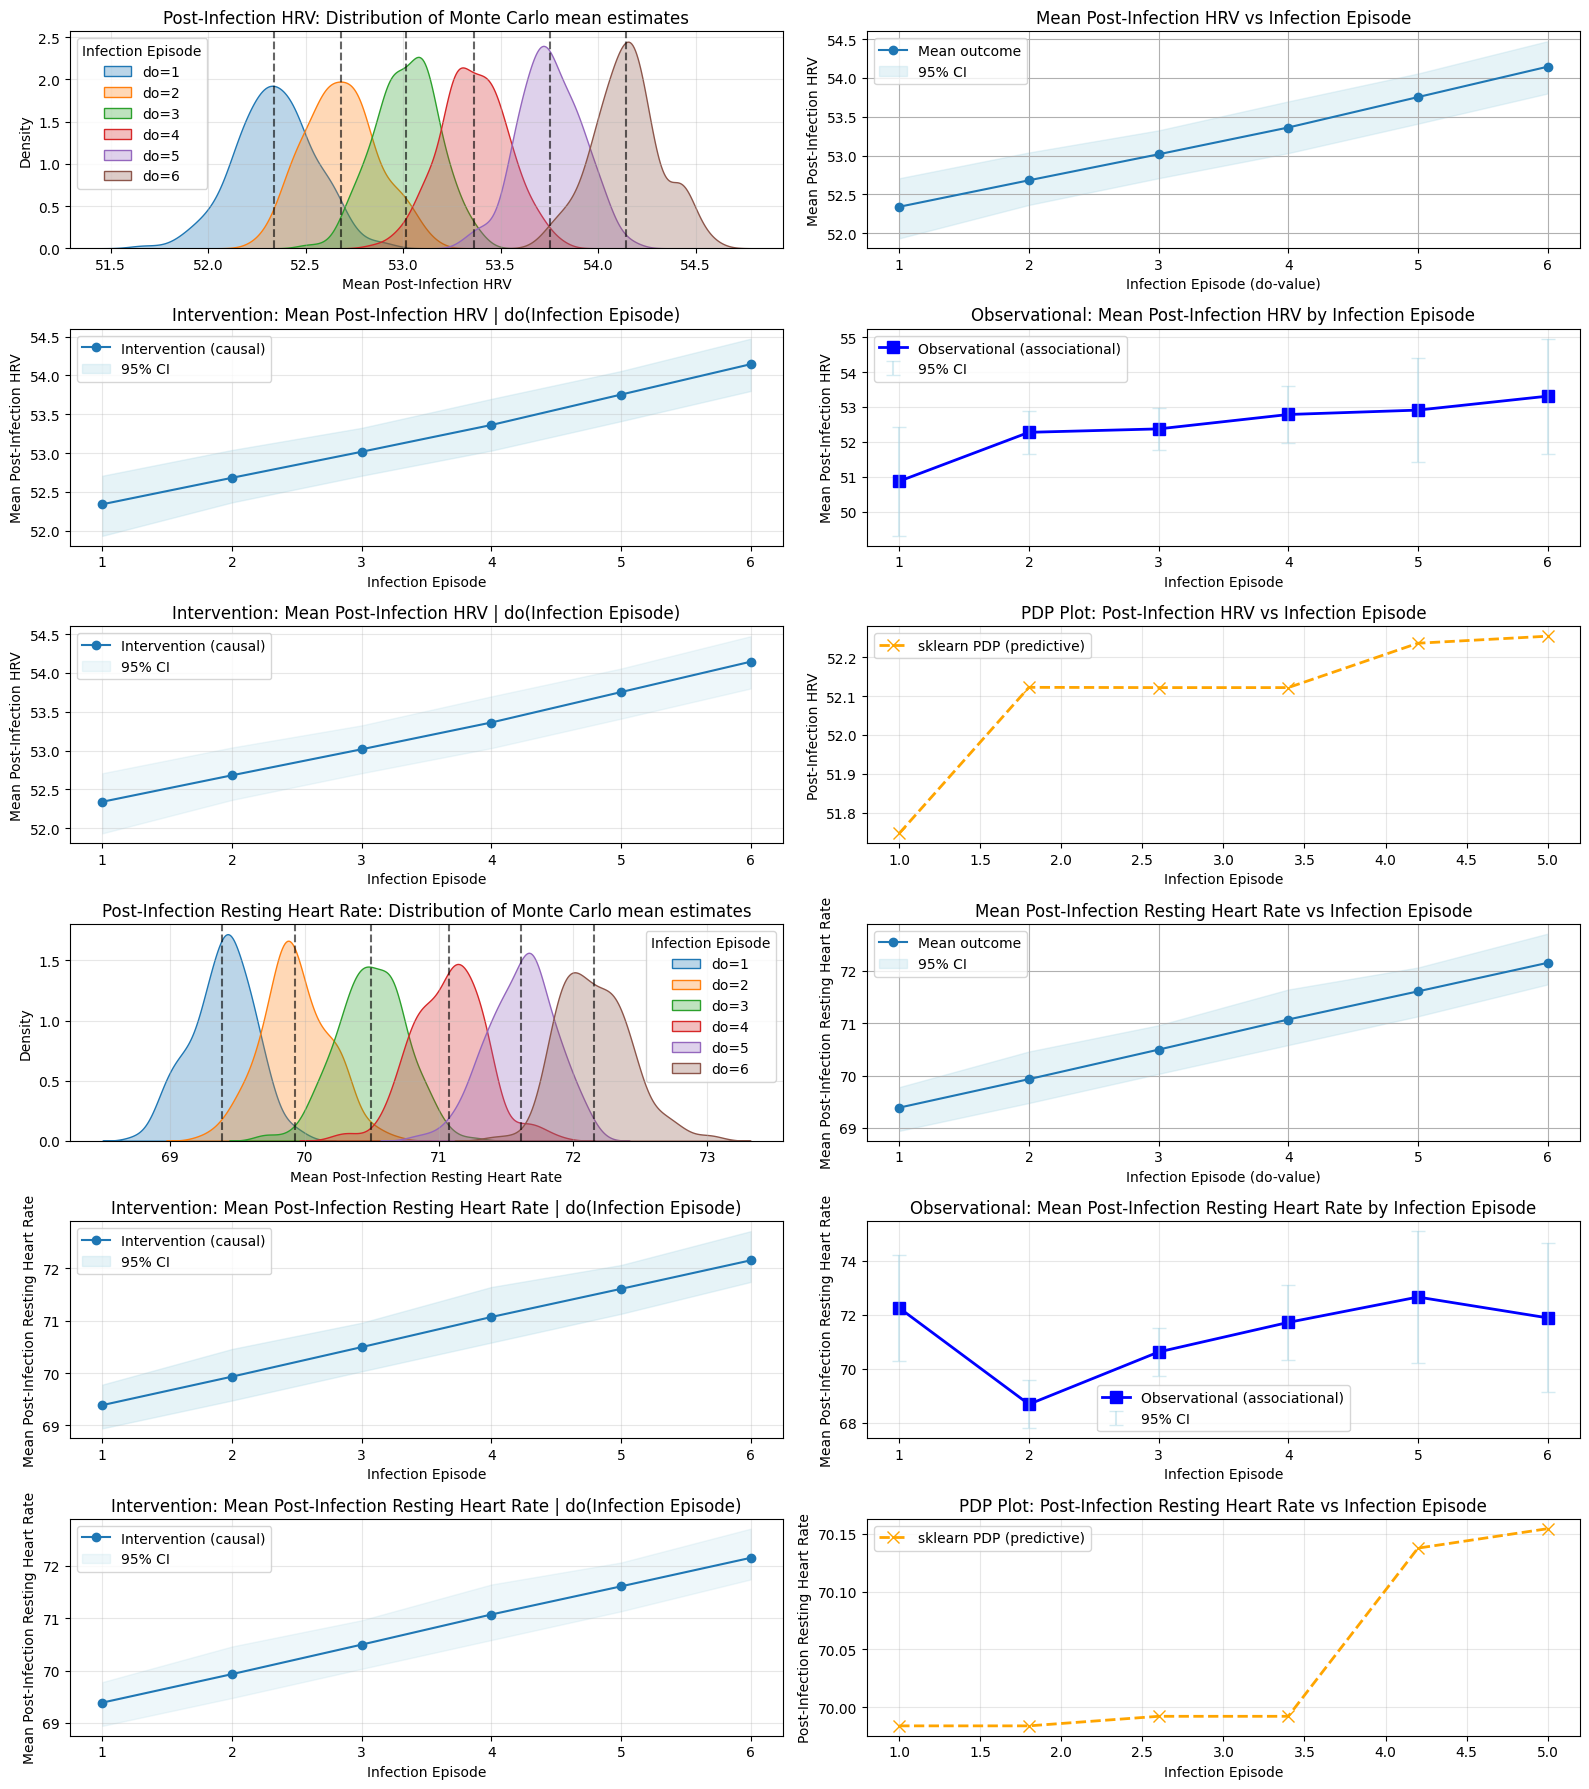

In [34]:
run_effect_and_interventions(G_best, scm_best, final_df_no_std, final_df_std, registry, treatments, other_outcomes, rq=2, n_reps=200)

#### Scenario 3: Other Factors -> Outcome Measures

Paths from age to post_num_symp_prop: []
Paths from age to post_symp_sev_prop: []
Paths from age to post_symp_freq_prop: []
Paths from is_female to post_num_symp_prop: []
Paths from is_female to post_symp_sev_prop: []
Paths from is_female to post_symp_freq_prop: []
Paths from long_covid to post_num_symp_prop: []
Paths from long_covid to post_symp_sev_prop: []
Paths from long_covid to post_symp_freq_prop: []
Paths from me_cfs to post_num_symp_prop: []
Paths from me_cfs to post_symp_sev_prop: []
Paths from me_cfs to post_symp_freq_prop: []
Paths from fibromyalgia to post_num_symp_prop: []
Paths from fibromyalgia to post_symp_sev_prop: []
Paths from fibromyalgia to post_symp_freq_prop: []
Paths from dysautonomia to post_num_symp_prop: []
Paths from dysautonomia to post_symp_sev_prop: []
Paths from dysautonomia to post_symp_freq_prop: []
Paths from period_at_covid_start to post_num_symp_prop: []
Paths from period_at_covid_start to post_symp_sev_prop: []
Paths from period_at_covid_start to 

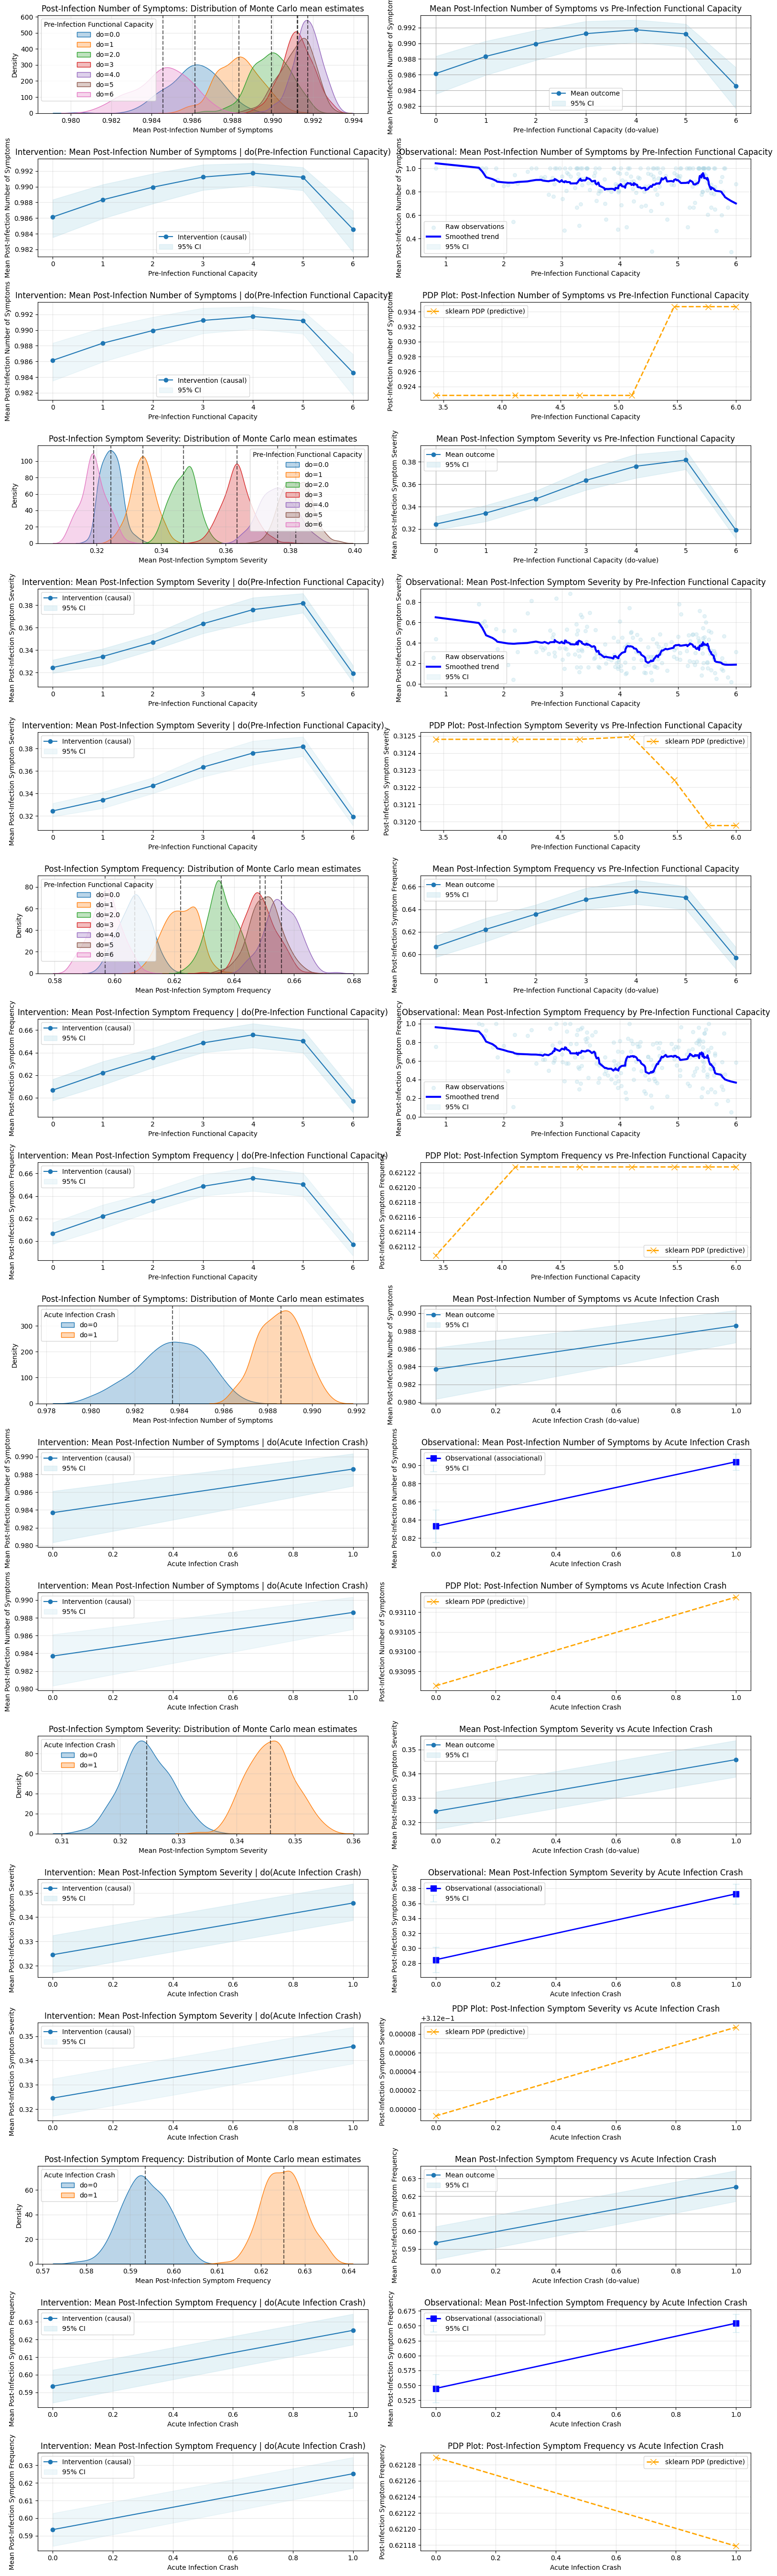

In [35]:
run_effect_and_interventions(G_best, scm_best, final_df_no_std, final_df_std, registry, other_treatments, outcomes, rq=3, n_reps=200)

### Consensus graph edge analysis

In [59]:
def consensus_graph_stability_analysis(G):
    
    # 1. Edge Stability Analysis
    edge_weights = nx.get_edge_attributes(G, 'weight')

    edges = [(u, v, edge_weights.get((u,v), 0)) 
                    for u, v in G.edges()]
    highly_stable = [(u, v, edge_weights.get((u,v), 0)) 
                    for u, v in G.edges() if edge_weights.get((u,v),0) >= .85]
    moderately_stable = [(u, v, edge_weights.get((u,v), 0)) 
                    for u, v in G.edges() if edge_weights.get((u,v),0) >= .6 and edge_weights.get((u,v),0) < .85]
    unstable = [(u, v, edge_weights.get((u,v), 0)) 
                    for u, v in G.edges() if edge_weights.get((u,v),0) >= .35 and edge_weights.get((u,v),0) < .6]
    print(f"\nHighly stable edges (≥85%): {len(highly_stable)}")
    print(f"Moderately stable edges (60-84%): {len(moderately_stable)}")
    print(f"Unstable edges (<60%): {len(unstable)}")

    # 2. Critical Bottlenecks
    # Find nodes that are "hubs" in the stable network
    # Count stable edges in/out of each node

    outgoing_stable = Counter(u for u,v,w in highly_stable)
    incoming_stable = Counter(v for u,v,w in highly_stable)

    outgoing = Counter(u for u,v,w in edges)
    incoming = Counter(v for u,v,w in edges)

    print("\nNodes with most edge frequencies over 85%:")
    print("Top 10 outgoing:")
    for node, count in outgoing_stable.most_common(10):
        print(f"  {node}: {count} stable outgoing edges")

    print("\nTop 10 incoming:")
    for node, count in incoming_stable.most_common(10):
        print(f"  {node}: {count} stable incoming edges")

    # 3. Most Stable Edges
    print("\nEdges with most stable frequencies:")
    print("Top 75 edges:")
    for u,v,w in sorted(highly_stable, key=lambda x: (-x[2]))[:75]:
        print(u,v,w)

In [60]:
consensus_graph_stability_analysis(G_best)


Highly stable edges (≥85%): 154
Moderately stable edges (60-84%): 54
Unstable edges (<60%): 34

Nodes with most edge frequencies over 85%:
Top 10 outgoing:
  pre_emotionally_stressful: 14 stable outgoing edges
  pre_symp_sev_prop: 12 stable outgoing edges
  pre_physically_active: 11 stable outgoing edges
  pre_sleep: 9 stable outgoing edges
  pre_mentally_demanding: 8 stable outgoing edges
  pre_funcap_score: 7 stable outgoing edges
  age: 7 stable outgoing edges
  acute_physically_active: 6 stable outgoing edges
  acute_mentally_demanding: 6 stable outgoing edges
  acute_symp_freq_prop: 6 stable outgoing edges

Top 10 incoming:
  post_symp_freq_prop: 24 stable incoming edges
  post_symp_sev_prop: 24 stable incoming edges
  post_mentally_demanding: 15 stable incoming edges
  post_emotionally_stressful: 13 stable incoming edges
  acute_symp_freq_prop: 11 stable incoming edges
  acute_emotionally_stressful: 10 stable incoming edges
  acute_symp_sev_prop: 10 stable incoming edges
  acute

In [61]:
def consensus_graph_edge_analysis(G, treatment, outcome):
    
    # 1. Treatment Edge Analysis
    # Analyze the strength of the edges from the treatment
    print("\n1. Treatment Edge Analysis")
    edge_weights = nx.get_edge_attributes(G, 'weight')

    # Find edges FROM treatment
    treatment_edges = [(u, v, edge_weights.get((u,v), 0)) 
                    for u, v in G.edges() if u == treatment]

    print(f"Direct effects of {treatment}:")
    for u, v, weight in sorted(treatment_edges, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {u} → {v}: {weight:.3f}")

    # 2. Outcome Edge Analysis
    # Analyze the strength of the edges to the outcome
    print("\n2. Outcome Edge Analysis")

    # Find edges INTO outcome
    outcome_edges = [(u, v, edge_weights.get((u,v), 0)) 
                    for u, v in G.edges() if v == outcome]

    print(f"Direct edges into {outcome}:")
    for u, v, weight in sorted(outcome_edges, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {u} → {v}: {weight:.3f}")

In [62]:
# Check for all paths from treatment to outcome
treatment = 'infection_episode'
outcome = 'post_symp_sev_prop'

consensus_graph_edge_analysis(G_best, treatment, outcome)


1. Treatment Edge Analysis
Direct effects of infection_episode:
  infection_episode → pre_resting_hr: 0.610
  infection_episode → post_symp_sev_prop: 0.480
  infection_episode → acute_resting_hr: 0.370

2. Outcome Edge Analysis
Direct edges into post_symp_sev_prop:
  pre_symp_freq_prop → post_symp_sev_prop: 1.000
  acute_num_symp_prop → post_symp_sev_prop: 1.000
  acute_symp_freq_prop → post_symp_sev_prop: 1.000
  pre_resting_hr → post_symp_sev_prop: 1.000
  pre_emotionally_stressful → post_symp_sev_prop: 1.000
  post_symp_freq_prop → post_symp_sev_prop: 1.000
  acute_emotionally_stressful → post_symp_sev_prop: 1.000
  post_resting_hr → post_symp_sev_prop: 1.000
  post_num_symp_prop → post_symp_sev_prop: 1.000
  post_funcap_score → post_symp_sev_prop: 1.000
  acute_sleep → post_symp_sev_prop: 1.000
  post_crash → post_symp_sev_prop: 1.000
  pre_mentally_demanding → post_symp_sev_prop: 0.990
  acute_mentally_demanding → post_symp_sev_prop: 0.990
  pre_sleep → post_symp_sev_prop: 0.990


In [63]:
# Check for all paths from treatment to outcome
treatment = 'infection_episode'
outcome = 'post_symp_freq_prop'

consensus_graph_edge_analysis(G_best, treatment, outcome)


1. Treatment Edge Analysis
Direct effects of infection_episode:
  infection_episode → pre_resting_hr: 0.610
  infection_episode → post_symp_sev_prop: 0.480
  infection_episode → acute_resting_hr: 0.370

2. Outcome Edge Analysis
Direct edges into post_symp_freq_prop:
  pre_mentally_demanding → post_symp_freq_prop: 0.990
  acute_mentally_demanding → post_symp_freq_prop: 0.990
  acute_num_symp_prop → post_symp_freq_prop: 0.990
  pre_resting_hr → post_symp_freq_prop: 0.990
  pre_sleep → post_symp_freq_prop: 0.990
  pre_emotionally_stressful → post_symp_freq_prop: 0.990
  pre_funcap_score → post_symp_freq_prop: 0.990
  acute_emotionally_stressful → post_symp_freq_prop: 0.990
  post_resting_hr → post_symp_freq_prop: 0.990
  post_num_symp_prop → post_symp_freq_prop: 0.990
  post_funcap_score → post_symp_freq_prop: 0.990
  acute_crash → post_symp_freq_prop: 0.990
  acute_sleep → post_symp_freq_prop: 0.990
  pre_num_symp_prop → post_symp_freq_prop: 0.990
  post_crash → post_symp_freq_prop: 0.9

In [64]:
# Check for all paths from treatment to outcome
treatment = 'infection_episode'
outcome = 'acute_resting_hr'

consensus_graph_edge_analysis(G_best, treatment, outcome)


1. Treatment Edge Analysis
Direct effects of infection_episode:
  infection_episode → pre_resting_hr: 0.610
  infection_episode → post_symp_sev_prop: 0.480
  infection_episode → acute_resting_hr: 0.370

2. Outcome Edge Analysis
Direct edges into acute_resting_hr:
  pre_sleep → acute_resting_hr: 1.000
  pre_hr_variability → acute_resting_hr: 1.000
  age → acute_resting_hr: 1.000
  acute_hr_variability → acute_resting_hr: 1.000
  pre_resting_hr → acute_resting_hr: 0.980
  acute_sleep → acute_resting_hr: 0.970
  me_cfs → acute_resting_hr: 0.860
  acute_symp_sev_prop → acute_resting_hr: 0.840
  pre_symp_sev_prop → acute_resting_hr: 0.780
  acute_emotionally_stressful → acute_resting_hr: 0.740
  pre_emotionally_stressful → acute_resting_hr: 0.600
  pre_mentally_demanding → acute_resting_hr: 0.470
  acute_physically_active → acute_resting_hr: 0.400
  acute_mentally_demanding → acute_resting_hr: 0.400
  infection_episode → acute_resting_hr: 0.370


In [65]:
# Check for all paths from treatment to outcome
treatment = 'pre_sleep'
outcome = 'post_symp_sev_prop'

consensus_graph_edge_analysis(G_best, treatment, outcome)

# Check for all paths from treatment to outcome
treatment = 'acute_sleep'
outcome = 'post_symp_sev_prop'

consensus_graph_edge_analysis(G_best, treatment, outcome)

# Check for all paths from treatment to outcome
treatment = 'pre_emotionally_stressful'
outcome = 'post_symp_sev_prop'

consensus_graph_edge_analysis(G_best, treatment, outcome)


1. Treatment Edge Analysis
Direct effects of pre_sleep:
  pre_sleep → acute_symp_sev_prop: 1.000
  pre_sleep → acute_symp_freq_prop: 1.000
  pre_sleep → pre_symp_freq_prop: 1.000
  pre_sleep → acute_emotionally_stressful: 1.000
  pre_sleep → acute_resting_hr: 1.000
  pre_sleep → post_symp_sev_prop: 0.990
  pre_sleep → post_symp_freq_prop: 0.990
  pre_sleep → acute_sleep: 0.990
  pre_sleep → pre_resting_hr: 0.970
  pre_sleep → post_mentally_demanding: 0.790
  pre_sleep → acute_mentally_demanding: 0.760
  pre_sleep → post_sleep: 0.610
  pre_sleep → post_emotionally_stressful: 0.510

2. Outcome Edge Analysis
Direct edges into post_symp_sev_prop:
  pre_symp_freq_prop → post_symp_sev_prop: 1.000
  acute_num_symp_prop → post_symp_sev_prop: 1.000
  acute_symp_freq_prop → post_symp_sev_prop: 1.000
  pre_resting_hr → post_symp_sev_prop: 1.000
  pre_emotionally_stressful → post_symp_sev_prop: 1.000
  post_symp_freq_prop → post_symp_sev_prop: 1.000
  acute_emotionally_stressful → post_symp_sev_p

### Bootstrap graph path analysis

In [66]:
all_edges.head(2)

,bootstrap,edge,model
0,1,"('pre_symp_freq_prop', 'acute_symp_freq_prop')",pc
1,1,"('pre_resting_hr', 'acute_resting_hr')",pc


In [ ]:
def analyze_bootstrap_graphs(df, source_vars,
                                     target_vars,
                                     models=None,
                                     max_path_length=None):
    """
    Analyze pathway stability across bootstrap samples for multiple models.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with columns: 'model', 'bootstrap', 'edge'
        where edge is a tuple like ('source', 'target')
    source_vars : list
        List of source/treatment variables (e.g., ['infection_episode'])
    target_vars : list
        List of outcome variables (e.g., ['post_symp_sev_prop', ...])
    models : list, optional
        List of models to analyze. If None, analyzes all models in df
    max_path_length : int, optional
        Maximum path length to consider. If None, no limit
    
    Returns:
    --------
    dict : Nested dictionary with results for each model and source-target pair
    """
    
    if models is None:
        models = df['model'].unique()
    
    results = {}
    
    for model in models:
        print(f"\n{'='*60}")
        print(f"Analyzing: {model}")
        print(f"{'='*60}")
        
        model_df = df[df['model'] == model].copy()
        bootstraps = model_df['bootstrap'].unique()
        n_bootstraps = len(bootstraps)
        
        print(f"Number of bootstraps: {n_bootstraps}")

        # Pre-parse all edges and pre-build all graphs
        print(f"Pre-building {n_bootstraps} graphs...")
        bootstrap_graphs = {}
        for bootstrap_id in bootstraps:
            boot_edges = model_df[model_df['bootstrap'] == bootstrap_id]['edge'].tolist()
            boot_edges = [
                ast.literal_eval(e) if isinstance(e, str) else e 
                for e in boot_edges
            ]
            G_boot = nx.DiGraph()
            G_boot.add_edges_from(boot_edges)
            bootstrap_graphs[bootstrap_id] = G_boot
        print(f"Graphs built.")
        
        model_results = {
            'n_bootstraps': n_bootstraps,
            'source_target_pairs': {}
        }
        
        # Analyze each source-target pair
        for source in source_vars:
            for target in target_vars:
                
                print(f"\n--- {source} → {target} ---")
                
                pair_key = f"{source} → {target}"
                pair_results = {
                    'path_existence': 0,  # count of bootstraps with ANY path
                    'direct_edge': 0,     # count of bootstraps with direct edge
                    'all_paths': [],      # store all unique paths found
                    'path_counts': Counter(),  # count occurrences of each path
                    'path_lengths': [],   # distribution of path lengths
                    'mediator_frequency': Counter()  # how often each node mediates
                }
                
                # Analyze each bootstrap
                for bootstrap_id, G_boot in bootstrap_graphs.items():
                    print(f'bootstrap: {bootstrap_id}')

                    if G_boot.has_node(source):

                        # Check for direct edge
                        if G_boot.has_edge(source, target):
                            pair_results['direct_edge'] += 1

                        # Check for path existence
                        if nx.has_path(G_boot, source, target):
                            pair_results['path_existence'] += 1
                        
                        # Find all paths (with length limit if specified)
                        try:
                            if max_path_length:
                                paths = list(nx.all_simple_paths(G_boot, source, target, 
                                                                cutoff=max_path_length))
                            else:
                                paths = list(nx.all_simple_paths(G_boot, source, target))
                            
                            if paths:

                                mediators_this_bootstrap = set()
                                
                                for path in paths:
                                    # Store path as tuple for counting
                                    path_tuple = tuple(path)
                                    pair_results['path_counts'][path_tuple] += 1
                                    pair_results['path_lengths'].append(len(path))
                                    
                                    # Count mediators (nodes between source and target)
                                    mediators = path[1:-1]
                                    for mediator in mediators:
                                        mediators_this_bootstrap.add(mediator)  # set deduplicates

                                # Count each mediator once per bootstrap 
                                for mediator in mediators_this_bootstrap:
                                    pair_results['mediator_frequency'][mediator] += 1
                        
                        except nx.NetworkXNoPath:
                            continue
                        except Exception as e:
                            # print(f"Warning: Error finding paths in bootstrap {bootstrap_id}: {e}")
                            continue
                
                # Calculate percentages
                pair_results['path_existence_pct'] = 100 * pair_results['path_existence'] / n_bootstraps
                pair_results['direct_edge_pct'] = 100 * pair_results['direct_edge'] / n_bootstraps
                
                # Identify most common paths
                if pair_results['path_counts']:
                    total_path_instances = sum(pair_results['path_counts'].values())
                    pair_results['most_common_paths'] = [
                        {
                            'path': ' → '.join(path),
                            'count': count,
                            'pct_of_bootstraps': 100 * count / n_bootstraps,
                            'pct_of_path_instances': 100 * count / total_path_instances
                        }
                        for path, count in pair_results['path_counts'].most_common(10)
                    ]
                else:
                    pair_results['most_common_paths'] = []
                
                # Path length statistics
                if pair_results['path_lengths']:
                    pair_results['path_length_stats'] = {
                        'mean': np.mean(pair_results['path_lengths']),
                        'median': np.median(pair_results['path_lengths']),
                        'min': min(pair_results['path_lengths']),
                        'max': max(pair_results['path_lengths']),
                        'total_paths_found': len(pair_results['path_lengths'])
                    }
                else:
                    pair_results['path_length_stats'] = None
                
                # Top mediators
                if pair_results['mediator_frequency']:
                    pair_results['top_mediators'] = [
                        {
                            'node': node,
                            'appearances': count,
                            'pct_of_bootstraps': 100 * count / n_bootstraps
                        }
                        for node, count in pair_results['mediator_frequency'].most_common(10)
                    ]
                else:
                    pair_results['top_mediators'] = []
                
                model_results['source_target_pairs'][pair_key] = pair_results
        
        results[model] = model_results
    
    return results

In [92]:
def print_pathway_report(results, source_var, target_var, top_n_paths=5):
    """
    Print a formatted report for a specific source-target pair across all models.
    """
    pair_key = f"{source_var} → {target_var}"
    
    print(f"\n{'='*80}")
    print(f"PATHWAY ANALYSIS REPORT: {pair_key}")
    print(f"{'='*80}\n")
    
    for model, model_data in results.items():
        if pair_key not in model_data['source_target_pairs']:
            continue
            
        pair_data = model_data['source_target_pairs'][pair_key]
        n_bootstraps = model_data['n_bootstraps']
        
        print(f"\n{'-'*80}")
        print(f"Model: {model}")
        print(f"{'-'*80}")
        
        print(f"\n1. PATH EXISTENCE:")
        print(f"   - Any path exists: {pair_data['path_existence_pct']:.1f}% ({pair_data['path_existence']}/{n_bootstraps} bootstraps)")
        print(f"   - Direct edge exists: {pair_data['direct_edge_pct']:.1f}% ({pair_data['direct_edge']}/{n_bootstraps} bootstraps)")
        
        if pair_data['path_existence'] > 0:
            indirect_pct = pair_data['path_existence_pct'] - pair_data['direct_edge_pct']
            print(f"   - Indirect paths only: {indirect_pct:.1f}%")
        
        if pair_data['path_length_stats']:
            stats = pair_data['path_length_stats']
            print(f"\n2. PATH CHARACTERISTICS:")
            print(f"   - Total unique paths: {len(pair_data['path_counts'])}")
            print(f"   - Total path instances: {stats['total_paths_found']}")
            print(f"   - Mean length: {stats['mean']:.1f} nodes")
            print(f"   - Median length: {stats['median']:.1f} nodes")
            print(f"   - Range: {stats['min']}-{stats['max']} nodes")
        
        if pair_data['most_common_paths']:
            print(f"\n3. TOP {min(top_n_paths, len(pair_data['most_common_paths']))} MOST COMMON PATHWAYS:")
            for i, path_info in enumerate(pair_data['most_common_paths'][:top_n_paths], 1):
                print(f"   {i}. {path_info['path']}")
                print(f"      → Appears in {path_info['pct_of_bootstraps']:.1f}% of bootstraps ({path_info['count']} times)")
        
        if pair_data['top_mediators']:
            print(f"\n4. TOP 10 MEDIATING NODES:")
            for i, med_info in enumerate(pair_data['top_mediators'][:10], 1):
                print(f"   {i}. {med_info['node']}")
                print(f"      → Appears in {med_info['pct_of_bootstraps']:.1f}% of bootstraps ({med_info['appearances']} times)")

In [115]:
import time

df=all_edges
source_vars=treatments
target_vars=outcomes

model_df = df[df['model'] == 'lingam'].copy()
bootstraps = model_df['bootstrap'].unique()
n_bootstraps = len(bootstraps)

print(f"Number of bootstraps: {n_bootstraps}")

# Pre-parse all edges and pre-build all graphs
print(f"Pre-building {n_bootstraps} graphs...")
bootstrap_graphs = {}
for bootstrap_id in bootstraps:
    boot_edges = model_df[model_df['bootstrap'] == bootstrap_id]['edge'].tolist()
    boot_edges = [
        ast.literal_eval(e) if isinstance(e, str) else e 
        for e in boot_edges
    ]
    G_boot = nx.DiGraph()
    G_boot.add_edges_from(boot_edges)
    bootstrap_graphs[bootstrap_id] = G_boot
print(f"Graphs built.")

model_results = {
    'n_bootstraps': n_bootstraps,
    'source_target_pairs': {}
        }

# Pick one bootstrap graph and one pair
sample_boot = list(bootstrap_graphs.values())[0]
source = treatments[0]
target = outcomes[0]

# Pick one bootstrap graph and one pair
for boot in list(bootstrap_graphs.values()):
    # source = 'infection_episode'
    # target = 'post_num_symp_prop'

    # # Test 1: How long does a single all_simple_paths take on one bootstrap graph?
    # start = time.time()
    # paths = list(nx.all_simple_paths(sample_boot, source, target))
    # t1 = time.time() - start
    # print(f"1 bootstrap, 1 pair, no cutoff: {t1:.3f}s")
    # print(f"Number of paths found: {len(paths)}")

    # # Test 2: Path length distribution 
    # boot_lengths = pd.Series([len(p) for p in paths]).value_counts().sort_index()
    # print(f"\nBootstrap path length distribution:\n{boot_lengths}")

    # Test 3: Are there cycles in bootstrap graphs?
    print(f"Bootstrap graph is DAG: {nx.is_directed_acyclic_graph(boot)}")

# # Test 1: How long does a single all_simple_paths take on one bootstrap graph?
# start = time.time()
# paths = list(nx.all_simple_paths(sample_boot, source, target))
# t1 = time.time() - start
# print(f"1 bootstrap, 1 pair, no cutoff: {t1:.3f}s")
# print(f"Number of paths found: {len(paths)}")

# # Test 2: How long on the consensus graph?
# start = time.time()
# paths_consensus = list(nx.all_simple_paths(G_best, source, target))
# t2 = time.time() - start
# print(f"Consensus graph, 1 pair, no cutoff: {t2:.3f}s")
# print(f"Number of paths found: {len(paths_consensus)}")

# # Test 3: Path length distribution comparison
# boot_lengths = pd.Series([len(p) for p in paths]).value_counts().sort_index()
# consensus_lengths = pd.Series([len(p) for p in paths_consensus]).value_counts().sort_index()
# print(f"\nBootstrap path length distribution:\n{boot_lengths}")
# print(f"\nConsensus path length distribution:\n{consensus_lengths}")

# # Test 4: Are there cycles in bootstrap graphs?
# print(f"\nConsensus graph is DAG: {nx.is_directed_acyclic_graph(G_best)}")
# print(f"Bootstrap graph is DAG: {nx.is_directed_acyclic_graph(sample_boot)}")

Number of bootstraps: 100
Pre-building 100 graphs...
Graphs built.
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Bootstrap graph is DAG: False
Boo

In [113]:
# How many cycles exist in bootstrap graphs?
for i, (boot_id, G_boot) in enumerate(list(bootstrap_graphs.items())[:5]):
    try:
        cycles = list(nx.simple_cycles(G_boot))
        print(f"Bootstrap {boot_id}: {len(cycles)} cycles")
        if cycles:
            print(f"  Example cycle: {cycles[0]}")
    except:
        print(f"Bootstrap {boot_id}: cycle detection failed")

# Which edges are causing cycles? (edges not in consensus DAG)
consensus_edges = set(G_best.edges())
sample_boot = list(bootstrap_graphs.values())[0]
boot_edges = set(sample_boot.edges())

extra_edges = boot_edges - consensus_edges
reversed_edges = {(b, a) for (a, b) in extra_edges if (b, a) in consensus_edges}
print(f"\nEdges in bootstrap but not consensus: {len(extra_edges)}")
print(f"Of those, edges that REVERSE a consensus edge: {len(reversed_edges)}")
print(f"Reversed edges (likely causing cycles):")
for e in reversed_edges:
    print(f"  {e}")

Bootstrap 1: 791 cycles
  Example cycle: ['pre_resting_hr', 'pre_sleep', 'pre_mentally_demanding', 'pre_symp_freq_prop', 'pre_symp_sev_prop']
Bootstrap 2: 1355 cycles
  Example cycle: ['pre_resting_hr', 'pre_sleep', 'pre_mentally_demanding', 'pre_symp_freq_prop', 'pre_emotionally_stressful', 'pre_physically_active', 'pre_hr_variability']
Bootstrap 3: 1349 cycles
  Example cycle: ['pre_resting_hr', 'pre_sleep', 'pre_mentally_demanding', 'pre_symp_freq_prop', 'pre_physically_active', 'pre_emotionally_stressful']
Bootstrap 4: 1832 cycles
  Example cycle: ['pre_resting_hr', 'pre_sleep', 'pre_mentally_demanding', 'pre_symp_freq_prop', 'pre_physically_active', 'pre_emotionally_stressful']
Bootstrap 5: 735 cycles
  Example cycle: ['pre_resting_hr', 'pre_sleep', 'pre_emotionally_stressful', 'pre_symp_freq_prop', 'pre_symp_sev_prop', 'pre_physically_active', 'pre_mentally_demanding']

Edges in bootstrap but not consensus: 83
Of those, edges that REVERSE a consensus edge: 38
Reversed edges (like

In [ ]:
# =============================================================================
# MAIN ANALYSIS EXECUTION
# =============================================================================

# RQ1: infection_episode → symptoms
print("\n" + "="*80)
print("RESEARCH QUESTION 1: How do cumulative infections influence symptoms?")
print("="*80)

rq1_results = analyze_bootstrap_graphs(
    df=all_edges,
    source_vars=treatments,
    target_vars=outcomes,
    models=[best_model], 
    max_path_length=None 
)

# Print detailed reports for each treatment-outcome pair
for treatment in treatments:
    for outcome in outcomes:
        print_pathway_report(rq1_results, treatment, outcome, top_n_paths=10)


RESEARCH QUESTION 1: How do cumulative infections influence symptoms?

Analyzing: notears_nonlinear
Number of bootstraps: 100
Pre-building 100 graphs...
Graphs built.

--- infection_episode → post_num_symp_prop ---
bootstrap: 1
bootstrap: 2


KeyboardInterrupt: 

In [81]:
# =============================================================================
# MAIN ANALYSIS EXECUTION
# =============================================================================

# RQ1: infection_episode → symptoms
print("\n" + "="*80)
print("RESEARCH QUESTION 1: How do cumulative infections influence symptoms?")
print("="*80)

rq1_results = analyze_bootstrap_graphs(
    df=all_edges,
    source_vars=treatments,
    target_vars=outcomes,
    models=[best_model], 
    max_path_length=7  
)

# Print detailed reports for each treatment-outcome pair
for treatment in treatments:
    for outcome in outcomes:
        print_pathway_report(rq1_results, treatment, outcome, top_n_paths=10)

# RQ2: infection_episode → other outcomes
print("\n" + "="*80)
print("RESEARCH QUESTION 2: How do cumulative infections influence other outcomes?")
print("="*80)

print(f"Analyzing {len(other_outcomes)} other outcome variables...")

rq2_results = analyze_bootstrap_graphs(
    df=all_edges,
    source_vars=treatments,
    target_vars=other_outcomes,
    models=[best_model],
    max_path_length=7
)

# Print detailed reports for each treatment-outcome pair
for treatment in treatments:
    for outcome in other_outcomes:
        print_pathway_report(rq2_results, treatment, outcome, top_n_paths=10)

# RQ3: other factors → symptoms
print("\n" + "="*80)
print("RESEARCH QUESTION 3: How do other factors influence symptoms?")
print("="*80)

print(f"Analyzing {len(other_treatments)} treatment variables...")

rq3_results = analyze_bootstrap_graphs(
    df=all_edges,
    source_vars=other_treatments,
    target_vars=outcomes,  # same symptom outcomes as RQ1
    models=[best_model],
    max_path_length=7
)

# Print summary for top treatments (ones with stable paths)
print("\n" + "="*80)
print("RQ3 SUMMARY: Factors with stable pathways to symptoms")
print("="*80)

# Print detailed reports for each treatment-outcome pair
for treatment in other_treatments:
    for outcome in outcomes:
        print_pathway_report(rq3_results, treatment, outcome, top_n_paths=10)


RESEARCH QUESTION 1: How do cumulative infections influence symptoms?

Analyzing: notears_nonlinear
Number of bootstraps: 100

--- infection_episode → post_num_symp_prop ---
  Path existence: 0.0% of bootstraps
  Direct edge: 0.0% of bootstraps

--- infection_episode → post_symp_sev_prop ---
  Path existence: 92.0% of bootstraps
  Direct edge: 48.0% of bootstraps
  Total unique paths found: 304246
  Mean path length: 7.7
  Path length range: 2-8

--- infection_episode → post_symp_freq_prop ---
  Path existence: 91.0% of bootstraps
  Direct edge: 19.0% of bootstraps
  Total unique paths found: 304027
  Mean path length: 7.7
  Path length range: 2-8

PATHWAY ANALYSIS REPORT: infection_episode → post_num_symp_prop


--------------------------------------------------------------------------------
Model: notears_nonlinear
--------------------------------------------------------------------------------

1. PATH EXISTENCE:
   - Any path exists: 0.0% (0/100 bootstraps)
   - Direct edge exists

KeyboardInterrupt: 

In [ ]:
# # Get intervention grid in raw units
#         intervention_vals_raw = [inverse_outcome_transform(treatment, val, registry) for val in intervention_vals]
        
#         # Generate ICE curves (individual conditional expectation)
#         # Sample a subset of individuals for ICE
#         n_ice_samples = min(50, len(std_data))
#         ice_indices = np.random.choice(len(std_data), n_ice_samples, replace=False)
        
#         for ice_idx in ice_indices:
#             ice_outcomes = []
#             for treat_val_std in intervention_vals:
#                 # Create counterfactual: set treatment to this value
#                 cf_data = std_data.copy()
#                 cf_data.loc[ice_idx, treatment] = treat_val_std
                
#                 # Predict outcome for this individual
#                 # Generate outcome using the SCM
#                 try:
#                     sample = gcm.draw_samples(scm, n_samples=1, noise_samples=cf_data.iloc[[ice_idx]])
#                     ice_outcomes.append(inverse_outcome_transform(outcome, sample[outcome].iloc[0], registry))
#                 except:
#                     # Fallback: use the causal mechanism directly
#                     sample_outcome = cf_data.iloc[ice_idx][outcome]
#                     ice_outcomes.append(inverse_outcome_transform(outcome, sample_outcome, registry))
            
#             ax_pdp.plot(intervention_vals_raw, ice_outcomes, alpha=0.1, color='blue', linewidth=0.5)
        
#         ## Add PDP (average of ICE curves) - use the mean_raw dictionary values
#         # Sort by treatment value to ensure proper ordering
#         pdp_data = sorted([(k, v) for k, v in mean_raw.items()], key=lambda x: x[0])
#         pdp_treatment_vals = [x[0] for x in pdp_data]
#         pdp_outcomes = [x[1] for x in pdp_data]
        
#         ax_pdp.plot(pdp_treatment_vals, pdp_outcomes, color='green', linewidth=3, 
#                    label='PDP (population average)', marker='o', markersize=8, zorder=10)